In [3]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION — MERGED PIPELINE (UPDATED BASELINE)
=======================================================

What this script does (one run, all outputs):
  A) Baseline ridge reconstruction using a *restricted lag range* (default: lag<=MAX_LAG_ALLOWED)
     - This fixes the "baseline looks off" issue caused by maxlag=49 + tons of weak long-lag junk.
  B) Rank features by |corr(PC(t-lag), AMOC(t))| on the same allowed lag range
  C) Fit ridge on Top-100 seed features + lag-window expansion ±LAG_WINDOW
  D) R² evolution curve: N=1..100 seeds (each expanded by lag-window) -> test R²

Lag convention:
  lag >= 0 means we use PC[t-lag] to predict AMOC[t].

Outputs saved in OUTDIR:
  - baseline_* (time, Ytrue, Ypred, meta)
  - top100_* (time, Ytrue, Ypred, meta)
  - feature_ranking_by_abs_corr.csv
  - top100_seed_window_expanded_features.csv
  - r2_curve_top1_to_top100.csv
  - plots: r2_curve_plot.png, timeseries_baseline_test.png, timeseries_top100_test.png

Notes:
  - Uses ensemble-mean PCs if "member" dimension exists.
  - Chronological train/test split.
"""

import os
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score


# ============================================================
# CONFIG
# ============================================================

MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"   # or "AMOC_26N_ensmean"

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]

N_MODES = 10

# Total lag universe (only matters if you set MAX_LAG_ALLOWED=None)
MAX_LAG_TOTAL = 50

# ✅ Key baseline fix:
# Restrict baseline + ranking + window-expansion to this lag maximum.
# Set None if you *really* want 0..MAX_LAG_TOTAL-1 everywhere.
MAX_LAG_ALLOWED = 25

TEST_FRAC = 0.2

# Ridge alpha scan (denser grid helps)
RIDGE_ALPHAS = np.logspace(-6, 6, 25)

# Top feature experiments
TOP_N_MAX = 100

# Lag window expansion around each top-N seed feature
LAG_WINDOW = 2

# Optional redundancy control: cap number of unique lags per (var,lon,mode) AFTER expansion
CAP_LAGS_PER_GROUP = None   # e.g. 10, or None

# Files
EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = f"/data/users/frekle/AMOC_reconstruction/Feature_reduction/{MODEL}/{TARGET}/" \
         f"m{N_MODES}_lags{MAX_LAG_TOTAL}_lagmax{MAX_LAG_ALLOWED}_win{LAG_WINDOW}/"
os.makedirs(OUTDIR, exist_ok=True)


# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    """Robust year extraction for cftime/numpy datetime."""
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc_ensmean(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))

    if "member" in PC.dims:
        PC = PC.mean("member")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    return PC.astype(float)  # (year, mode)

def load_amoc_1d(target):
    dsA = xr.open_dataset(AMOC_FILE)
    am = dsA[target].squeeze()
    years = extract_years(am["time"])
    am = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    am = am.astype(float).squeeze()
    if am.ndim != 1:
        raise ValueError(f"AMOC target not 1D after squeeze: shape={am.shape}")
    return am  # (year,)

def corr_1d(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return float(np.sum(aa * bb) / denom)

def fit_ridge_alpha_scan(X_train, Y_train, X_test, Y_test, alphas):
    best = None
    for a in alphas:
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(a)))
        mdl.fit(X_train, Y_train)
        pred = mdl.predict(X_test)
        r2 = float(r2_score(Y_test, pred))
        if best is None or r2 > best["r2"]:
            best = {"alpha": float(a), "model": mdl, "pred": pred, "r2": r2}
    best["pred_train"] = best["model"].predict(X_train)
    return best

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred))
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    return r2, r, var_ratio, mae, rmse

# ---------- Feature builders ----------

def allowed_lags():
    """Which lags are allowed everywhere (baseline, ranking, top features)."""
    if MAX_LAG_ALLOWED is None:
        return list(range(MAX_LAG_TOTAL))
    return list(range(int(MAX_LAG_ALLOWED) + 1))

def build_feature_list(var_list, lon_list, n_modes, lag_list):
    feats = []
    for var in var_list:
        for lon in lon_list:
            for m in range(n_modes):
                for lag in lag_list:
                    feats.append((var, lon, int(m), int(lag)))
    return feats

def build_X_from_features(pc_np, years, feats):
    """
    feats: list of (var, lon, mode0, lag>=0) meaning use PC[t-lag] to predict Y[t]
    Returns:
      X, time_out, max_lag_used
    """
    years = np.asarray(years).astype(int)
    T = len(years)
    if len(feats) == 0:
        raise ValueError("No features provided.")

    max_lag = int(max(lag for (_, _, _, lag) in feats))
    rows = []
    t_out = []

    for t in range(max_lag, T):
        xrow = []
        for (var, lon, m, lag) in feats:
            xrow.append(pc_np[(var, lon)][t - lag, m])
        rows.append(xrow)
        t_out.append(years[t])

    return np.asarray(rows, float), np.asarray(t_out, int), max_lag

def expand_lag_window(seed_feats, lag_window, max_lag_allowed=None, cap_lags_per_group=None):
    """
    seed_feats: list of (var,lon,mode0,lag)
    expands each lag to [lag-W..lag+W], obeying bounds and optional cap per (var,lon,mode0).
    returns sorted unique list.
    """
    expanded = []
    for (var, lon, m, lag) in seed_feats:
        for L in range(int(lag) - int(lag_window), int(lag) + int(lag_window) + 1):
            if L < 0:
                continue
            if max_lag_allowed is not None and L > int(max_lag_allowed):
                continue
            expanded.append((var, lon, m, int(L)))

    # optional cap unique lags per (var,lon,mode)
    if cap_lags_per_group is not None:
        keep = []
        seen = {}
        for feat in expanded:
            key = (feat[0], feat[1], feat[2])
            seen.setdefault(key, set())
            if feat[3] not in seen[key]:
                if len(seen[key]) < int(cap_lags_per_group):
                    seen[key].add(feat[3])
                    keep.append(feat)
        expanded = keep

    return sorted(set(expanded), key=lambda x: (x[0], x[1], x[2], x[3]))

def rank_features_by_corr_trainonly(pc_np, amoc, years, feats, train_end_year):
    """
    Rank features by abs corr using TRAIN YEARS ONLY (no leakage).
    """
    years = np.asarray(years).astype(int)
    T = len(years)
    y = np.asarray(amoc, float)

    train_mask = years <= int(train_end_year)

    rows = []
    for (var, lon, m, lag) in feats:
        if lag >= T:
            continue

        t_idx = np.arange(lag, T)
        p_idx = t_idx - lag

        # ✅ restrict to TRAIN target years only
        t_idx = t_idx[train_mask[t_idx]]
        p_idx = t_idx - lag

        if len(t_idx) < 5:
            continue

        pp = pc_np[(var, lon)][p_idx, m]
        yy = y[t_idx]

        c = corr_1d(pp, yy)
        if not np.isfinite(c):
            continue

        rows.append({
            "var": var,
            "lon": lon,
            "mode0": int(m),
            "mode": int(m + 1),
            "lag": int(lag),
            "corr": float(c),
            "abs_corr": float(abs(c)),
        })

    df = pd.DataFrame(rows)
    df = df.sort_values("abs_corr", ascending=False).reset_index(drop=True)
    return df


# ============================================================
# LOAD PCs + AMOC + ALIGN YEARS
# ============================================================

print("Loading EOF PCs (ensemble mean)...")
pc_dict = {}
for var in VARS:
    for lon in LON_TAGS:
        pc_dict[(var, lon)] = load_pc_ensmean(var, lon, N_MODES)
        print(f"  ✓ {var} {lon} PC: {tuple(pc_dict[(var, lon)].shape)}")

print("Loading AMOC...")
AMOC = load_amoc_1d(TARGET)

# Common years across everything
common_years = AMOC["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years).astype(int)
common_years.sort()

AMOCc = AMOC.sel(year=common_years).values.astype(float).squeeze()
pc_np = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}

print(f"✓ Common years: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")


# ============================================================
# DEFINE ALLOWED FEATURE SPACE (lags)
# ============================================================

LAGS_ALLOWED = allowed_lags()
print(f"\nUsing allowed lags: 0..{max(LAGS_ALLOWED)}  (count={len(LAGS_ALLOWED)})")


# ============================================================
# A) BASELINE: ALL FEATURES (restricted lags)
# ============================================================

print("\n[A] Baseline ridge on ALL features (restricted lags)...")
baseline_feats = build_feature_list(VARS, LON_TAGS, N_MODES, LAGS_ALLOWED)
X_all, t_all, maxlag_all = build_X_from_features(pc_np, common_years, baseline_feats)
Y_all = AMOCc[maxlag_all:]

n_train = int((1 - TEST_FRAC) * len(X_all))
Xtr, Xte = X_all[:n_train], X_all[n_train:]
Ytr, Yte = Y_all[:n_train], Y_all[n_train:]
t_test = t_all[n_train:]

# ✅ Train cutoff year (for ranking only)
train_end_year = int(t_all[n_train - 1])
print(f"Ranking will use TRAIN only: years ≤ {train_end_year}")

base = fit_ridge_alpha_scan(Xtr, Ytr, Xte, Yte, RIDGE_ALPHAS)
base_pred = base["pred"]
base_met = metrics(Yte, base_pred)

print(f"✓ BASELINE alpha={base['alpha']:.3g}  R²={base_met[0]:.4f}  corr={base_met[1]:.4f}  var={base_met[2]:.3f}")
print(f"  sanity: std(y_true)={np.std(Yte):.4f}  std(y_pred)={np.std(base_pred):.4f}  "
      f"mean(y_true)={np.mean(Yte):.4f}  mean(y_pred)={np.mean(base_pred):.4f}")

# Save baseline
np.save(os.path.join(OUTDIR, "baseline_time.npy"), t_test)
np.save(os.path.join(OUTDIR, "baseline_Ytrue.npy"), Yte.astype(np.float32))
np.save(os.path.join(OUTDIR, "baseline_Ypred.npy"), base_pred.astype(np.float32))
np.save(os.path.join(OUTDIR, "baseline_meta.npy"),
        np.array([base["alpha"], base_met[0], base_met[1], base_met[2], base_met[3], base_met[4],
                  len(baseline_feats), maxlag_all], float))


# ============================================================
# B) RANK FEATURES BY CORR (same allowed lag range)
# ============================================================

print("\n[B] Ranking features by |corr| (PC[t-lag] vs AMOC[t]) on allowed lags...")
df_rank = rank_features_by_corr_trainonly(
    pc_np=pc_np,
    amoc=AMOCc,
    years=common_years,
    feats=baseline_feats,
    train_end_year=train_end_year
)

rank_csv = os.path.join(OUTDIR, "feature_ranking_by_abs_corr.csv")
df_rank.to_csv(rank_csv, index=False)
print("Saved ranking:", rank_csv)
print("Top 10 ranked features:")
print(df_rank.head(10))


# ============================================================
# B2) TOP-100 + WINDOW
# ============================================================

print(f"\n[B2] Fit ridge on TOP-{TOP_N_MAX} seeds with lag-window ±{LAG_WINDOW} ...")

df_top = df_rank.head(TOP_N_MAX)
seed_feats = [(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])) for _, r in df_top.iterrows()]

feats100 = expand_lag_window(
    seed_feats=seed_feats,
    lag_window=LAG_WINDOW,
    max_lag_allowed=max(LAGS_ALLOWED),
    cap_lags_per_group=CAP_LAGS_PER_GROUP
)

X_100, t_100, maxlag_100 = build_X_from_features(pc_np, common_years, feats100)
Y_100 = AMOCc[maxlag_100:]

n_train100 = int((1 - TEST_FRAC) * len(X_100))
Xtr2, Xte2 = X_100[:n_train100], X_100[n_train100:]
Ytr2, Yte2 = Y_100[:n_train100], Y_100[n_train100:]
t_test2 = t_100[n_train100:]

top100 = fit_ridge_alpha_scan(Xtr2, Ytr2, Xte2, Yte2, RIDGE_ALPHAS)
pred100 = top100["pred"]
met100 = metrics(Yte2, pred100)

print(f"✓ TOP100 alpha={top100['alpha']:.3g}  R²={met100[0]:.4f}  corr={met100[1]:.4f}  var={met100[2]:.3f}")
print(f"  expanded feats={len(feats100)}  maxlag_used={maxlag_100}")

pd.DataFrame(feats100, columns=["var", "lon", "mode0", "lag"]).to_csv(
    os.path.join(OUTDIR, "top100_seed_window_expanded_features.csv"), index=False
)

np.save(os.path.join(OUTDIR, "top100_time.npy"), t_test2)
np.save(os.path.join(OUTDIR, "top100_Ytrue.npy"), Yte2.astype(np.float32))
np.save(os.path.join(OUTDIR, "top100_Ypred.npy"), pred100.astype(np.float32))
np.save(os.path.join(OUTDIR, "top100_meta.npy"),
        np.array([top100["alpha"], met100[0], met100[1], met100[2], met100[3], met100[4],
                  len(feats100), maxlag_100], float))


# ============================================================
# C) R² EVOLUTION: TOP-1 → TOP-100 (each with lag-window expansion)
# ============================================================

print(f"\n[C] R² evolution curve for N=1..{TOP_N_MAX} (with lag-window ±{LAG_WINDOW})...")

curve_rows = []
bestN = None

for N in range(1, TOP_N_MAX + 1):
    df_topN = df_rank.head(N)
    seedsN = [(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])) for _, r in df_topN.iterrows()]

    featsN = expand_lag_window(
        seed_feats=seedsN,
        lag_window=LAG_WINDOW,
        max_lag_allowed=max(LAGS_ALLOWED),
        cap_lags_per_group=CAP_LAGS_PER_GROUP
    )

    XN, tN, maxlagN = build_X_from_features(pc_np, common_years, featsN)
    YN = AMOCc[maxlagN:]

    n_trainN = int((1 - TEST_FRAC) * len(XN))
    XtrN, XteN = XN[:n_trainN], XN[n_trainN:]
    YtrN, YteN = YN[:n_trainN], YN[n_trainN:]

    resN = fit_ridge_alpha_scan(XtrN, YtrN, XteN, YteN, RIDGE_ALPHAS)
    metN = metrics(YteN, resN["pred"])

    curve_rows.append([
        N, len(featsN), maxlagN, resN["alpha"],
        metN[0], metN[1], metN[2], metN[3], metN[4]
    ])

    if bestN is None or metN[0] > bestN["r2"]:
        bestN = {"N": N, "r2": metN[0], "alpha": resN["alpha"], "nfeats": len(featsN), "maxlag": maxlagN}

    if N in [1, 2, 5, 10, 20, 50, 100]:
        print(f"  N={N:3d}  feats={len(featsN):4d}  maxlag={maxlagN:2d}  alpha={resN['alpha']:<8.3g}  R²={metN[0]: .4f}")

df_curve = pd.DataFrame(
    curve_rows,
    columns=["N_seeds", "n_features_after_window", "max_lag_used", "alpha",
             "r2", "corr", "var_ratio", "mae", "rmse"]
)
curve_csv = os.path.join(OUTDIR, "r2_curve_top1_to_top100.csv")
df_curve.to_csv(curve_csv, index=False)

print("Saved:", curve_csv)
print(f"✓ Best N by test R²: N={bestN['N']}  feats={bestN['nfeats']}  maxlag={bestN['maxlag']}  "
      f"alpha={bestN['alpha']:.3g}  R²={bestN['r2']:.4f}")


# ============================================================
# PLOTS
# ============================================================

# R² curve
plt.figure(figsize=(10, 4))
plt.plot(df_curve["N_seeds"], df_curve["r2"], marker="o", markersize=3)
plt.axhline(base_met[0], linestyle="--", label=f"Baseline ALL (R²={base_met[0]:.2f})")
plt.axhline(met100[0], linestyle=":", label=f"Top100+window (R²={met100[0]:.2f})")
plt.xlabel("Top-N seed features (ranked by |corr|)")
plt.ylabel("Test R²")
plt.title(f"{MODEL} {TARGET} — R² evolution (lag-window ±{LAG_WINDOW}, lagmax={max(LAGS_ALLOWED)})")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
f_curve = os.path.join(OUTDIR, "r2_curve_plot.png")
plt.savefig(f_curve, dpi=300)
plt.close()
print("Saved:", f_curve)

# Timeseries: baseline
plt.figure(figsize=(12, 5))
plt.plot(t_test, Yte, lw=2, color="black", label="AMOC true (baseline test)")
plt.plot(t_test, base_pred, lw=2, label=f"Baseline ALL feats (R²={base_met[0]:.2f})")
plt.xlabel("Year")
plt.ylabel("AMOC [Sv]")
plt.title(f"{MODEL} — Baseline ALL-features reconstruction (test)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
f_ts1 = os.path.join(OUTDIR, "timeseries_baseline_test.png")
plt.savefig(f_ts1, dpi=300)
plt.close()
print("Saved:", f_ts1)

# Timeseries: top100
plt.figure(figsize=(12, 5))
plt.plot(t_test2, Yte2, lw=2, color="black", label="AMOC true (top100 test)")
plt.plot(t_test2, pred100, lw=2, label=f"Top100+window (R²={met100[0]:.2f})")
plt.xlabel("Year")
plt.ylabel("AMOC [Sv]")
plt.title(f"{MODEL} — Top100+window reconstruction (test)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
f_ts2 = os.path.join(OUTDIR, "timeseries_top100_test.png")
plt.savefig(f_ts2, dpi=300)
plt.close()
print("Saved:", f_ts2)


print("\n✅ DONE.")
print("OUTDIR:", OUTDIR)


Loading EOF PCs (ensemble mean)...
  ✓ thetao W10p0 PC: (165, 10)
  ✓ thetao W20p0 PC: (165, 10)
  ✓ thetao W30p0 PC: (165, 10)
  ✓ thetao W40p0 PC: (165, 10)
  ✓ thetao W60p0 PC: (165, 10)
  ✓ so W10p0 PC: (165, 10)
  ✓ so W20p0 PC: (165, 10)
  ✓ so W30p0 PC: (165, 10)
  ✓ so W40p0 PC: (165, 10)
  ✓ so W60p0 PC: (165, 10)
Loading AMOC...
✓ Common years: 1850–2014 (T=165)

Using allowed lags: 0..25  (count=26)

[A] Baseline ridge on ALL features (restricted lags)...
Ranking will use TRAIN only: years ≤ 1986
✓ BASELINE alpha=1e-06  R²=0.2505  corr=0.8387  var=0.396
  sanity: std(y_true)=0.5159  std(y_pred)=0.2046  mean(y_true)=12.5532  mean(y_pred)=12.8150

[B] Ranking features by |corr| (PC[t-lag] vs AMOC[t]) on allowed lags...
Saved ranking: /data/users/frekle/AMOC_reconstruction/Feature_reduction/IPSL-CM6A-LR/AMOC_45N_ensmean/m10_lags50_lagmax25_win2/feature_ranking_by_abs_corr.csv
Top 10 ranked features:
      var    lon  mode0  mode  lag      corr  abs_corr
0      so  W10p0      4 

Loading EOF PCs (ensmean)...


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


Loading AMOC...
✓ Common years: 1850–2014 (T=165)
Year cutoffs: TRAIN <= 1958, VAL <= 1986, TEST > 1986

[A] Baseline: all features, lags 0..25
  feats=2600 alpha*=10        R²_test=+0.2492 corr=+0.8403

[B] Top-N seeds ranked by |corr| on TRAIN only + lag window
  N=  1 feats=   4 alpha*=1e-06    R²_val=-2.0588 R²_test=-1.7073
  N=  2 feats=   4 alpha*=1e-06    R²_val=-2.0588 R²_test=-1.7073
  N=  5 feats=  11 alpha*=1e-06    R²_val=-0.3372 R²_test=+0.7300
  N= 10 feats=  31 alpha*=10       R²_val=-0.2394 R²_test=+0.7106
  N= 20 feats=  52 alpha*=10       R²_val=+0.0891 R²_test=-0.1114
  N= 30 feats=  72 alpha*=10       R²_val=-0.3467 R²_test=-2.0782
  N= 40 feats= 111 alpha*=100      R²_val=-1.2356 R²_test=-0.2347
  N= 50 feats= 124 alpha*=100      R²_val=-1.1090 R²_test=-0.0134
  N= 75 feats= 180 alpha*=100      R²_val=-1.2898 R²_test=+0.5350
  N=100 feats= 233 alpha*=100      R²_val=-0.9823 R²_test=+0.5364
  ✓ Best B by VAL: N=20 feats=52  R²_test=-0.1114

[C] Group pruning: rank (

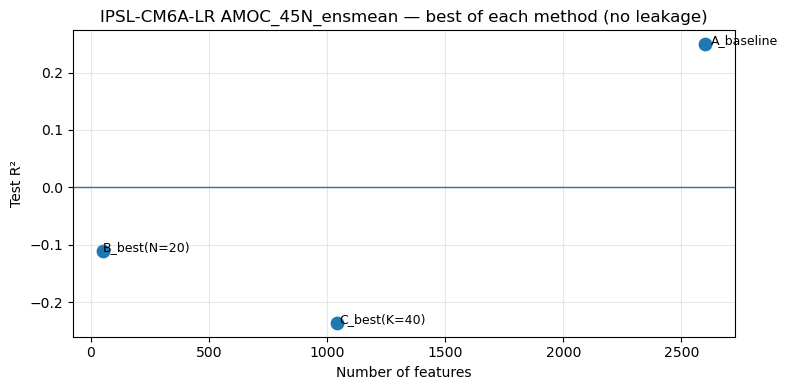

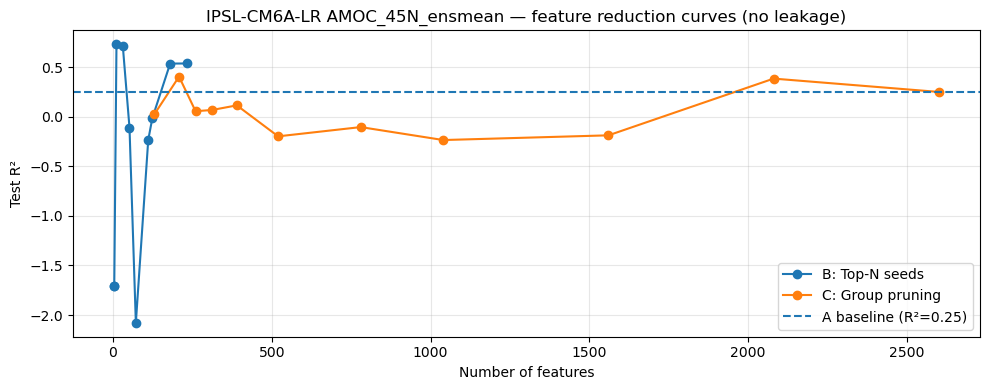

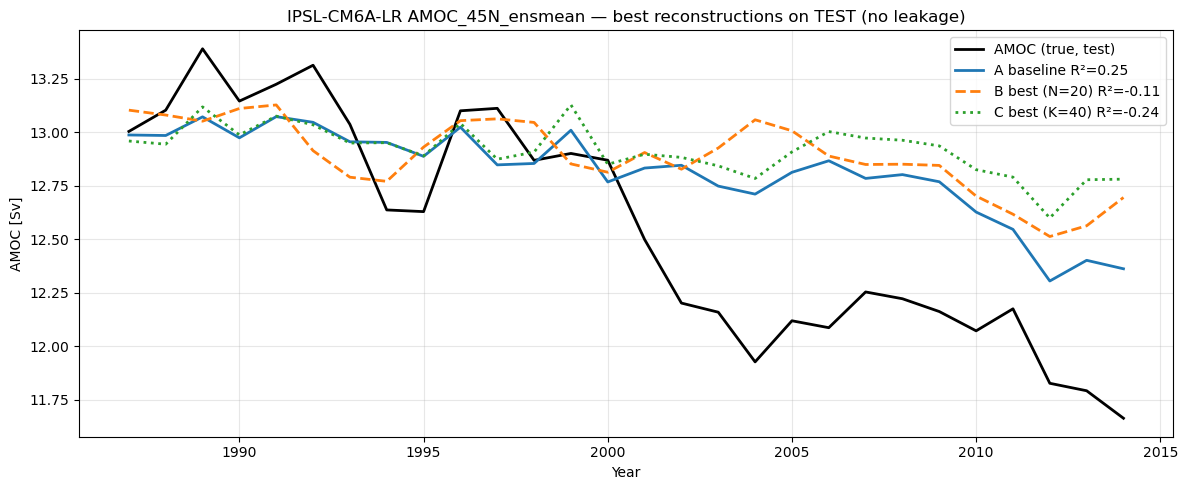


✅ DONE.
OUTDIR: /data/users/frekle/AMOC_reconstruction/Feature_reduction_compare/IPSL-CM6A-LR/AMOC_45N_ensmean/


In [1]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION — FAIR FEATURE REDUCTION COMPARISON (NO TEST LEAKAGE)
------------------------------------------------------------------------
Global design:
- Fixed max lag: MAXLAG_GLOBAL = 25 (lags 0..25)
- One shared target timeline: years[MAXLAG_GLOBAL .. end]
- One shared chronological split on that timeline: train/val/test
- alpha chosen on VAL only; TEST never used for tuning

Methods:
(A) Baseline: all (var,lon,mode) with all lags 0..25
(B) Top-N seeds: rank (var,lon,mode,lag) by |corr| on TRAIN only,
                 take top-N, expand each seed by ±LAG_WINDOW, fit ridge
(C) Group pruning: fit baseline on TRAIN (alpha on VAL), rank (var,lon,mode)
                   by sum|coef| across lags, keep top-K groups (all lags), fit ridge
"""

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# CONFIG
# ============================================================
MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES = 10

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = f"/data/users/frekle/AMOC_reconstruction/Feature_reduction_compare/{MODEL}/{TARGET}/"
os.makedirs(OUTDIR, exist_ok=True)

MAXLAG_GLOBAL = 25                # lags 0..25
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.6, 0.2, 0.2

RIDGE_ALPHAS = [1e-6, 1e-4, 1e-2, 0.1, 1, 10, 100, 316, 1000, 1e4, 1e5]

# Approach B
TOPN_LIST  = [1, 2, 5, 10, 20, 30, 40, 50, 75, 100]
LAG_WINDOW = 2
CAP_LAGS_PER_GROUP = None

# Approach C
K_LIST = [5, 8, 10, 12, 15, 20, 30, 40, 60, 80, 100]  # max groups = 2*5*10 = 100

# ============================================================
# Helpers
# ============================================================
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def corr_1d(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return float(np.sum(aa * bb) / denom)

def time_split_indices(n):
    n_train = int(TRAIN_FRAC * n)
    n_val   = int(VAL_FRAC * n)
    i0 = 0
    i1 = n_train
    i2 = n_train + n_val
    i3 = n
    if i2 >= i3:
        raise ValueError("Split leaves no test samples.")
    return i0, i1, i2, i3

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    r2 = float(r2_score(y_true, y_pred))
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    return r2, r, var_ratio, mae, rmse

def choose_alpha_on_val(Xtr, Ytr, Xva, Yva, alphas):
    best = None
    for a in alphas:
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(a)))
        mdl.fit(Xtr, Ytr)
        pred = mdl.predict(Xva)
        r2v = float(r2_score(Yva, pred))
        if best is None or r2v > best["r2_val"]:
            best = {"alpha": float(a), "r2_val": r2v, "model": mdl}
    best["coef_train"] = best["model"].named_steps["ridge"].coef_.astype(float)
    return best

def refit_trainval_and_test(Xtr, Ytr, Xva, Yva, Xte, Yte, alpha):
    Xtv = np.vstack([Xtr, Xva])
    Ytv = np.concatenate([Ytr, Yva])
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha)))
    mdl.fit(Xtv, Ytv)
    pred = mdl.predict(Xte)
    return mdl, pred, metrics(Yte, pred)

# ============================================================
# Load data
# ============================================================
def load_pc_ensmean(var, lon_tag):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, N_MODES))
    if "member" in PC.dims:
        PC = PC.mean("member")
    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)

def load_amoc_1d():
    dsA = xr.open_dataset(AMOC_FILE)
    am = dsA[TARGET].squeeze()
    years = extract_years(am["time"])
    am = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    am = am.astype(float).squeeze()
    if am.ndim != 1:
        raise ValueError("AMOC target is not 1D.")
    return am

print("Loading EOF PCs (ensmean)...")
pc_dict = {(v, L): load_pc_ensmean(v, L) for v in VARS for L in LON_TAGS}
print("Loading AMOC...")
amoc_da = load_amoc_1d()

# Align years
common_years = amoc_da["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.sort(common_years.astype(int))

AMOC = amoc_da.sel(year=common_years).values.astype(float)
pc_np = {k: pc_dict[k].sel(year=common_years).values.astype(float) for k in pc_dict}  # (Tfull, mode)

Tfull = len(common_years)
print(f"✓ Common years: {common_years[0]}–{common_years[-1]} (T={Tfull})")

# Shared target timeline (global)
t_global = common_years[MAXLAG_GLOBAL:]        # years for Y[t]
Y_global = AMOC[MAXLAG_GLOBAL:]
nG = len(t_global)

i0G, i1G, i2G, i3G = time_split_indices(nG)
train_end_year = int(t_global[i1G - 1])
val_end_year   = int(t_global[i2G - 1])
print(f"Year cutoffs: TRAIN <= {train_end_year}, VAL <= {val_end_year}, TEST > {val_end_year}")

# ============================================================
# Feature builders on GLOBAL timeline
# ============================================================
# Column map convention: (var, lon, mode0, lag)
def build_X_from_feature_list(feats):
    feats = list(feats)
    X = np.empty((nG, len(feats)), dtype=float)
    for j, year in enumerate(t_global):
        # full index for this target year
        t_full = (MAXLAG_GLOBAL + j)
        for i, (var, lon, m, lag) in enumerate(feats):
            X[j, i] = pc_np[(var, lon)][t_full - lag, m]
    fmap = np.array(feats, dtype=object)
    return X, fmap

def all_features_lags_0_25():
    feats = []
    for lag in range(MAXLAG_GLOBAL + 1):
        for var in VARS:
            for lon in LON_TAGS:
                for m in range(N_MODES):
                    feats.append((var, lon, m, lag))
    return feats

# ============================================================
# A) BASELINE
# ============================================================
print("\n[A] Baseline: all features, lags 0..25")
featsA = all_features_lags_0_25()
X_A, fmap_A = build_X_from_feature_list(featsA)

Xtr, Xva, Xte = X_A[i0G:i1G], X_A[i1G:i2G], X_A[i2G:i3G]
Ytr, Yva, Yte = Y_global[i0G:i1G], Y_global[i1G:i2G], Y_global[i2G:i3G]
t_test = t_global[i2G:i3G]

selA = choose_alpha_on_val(Xtr, Ytr, Xva, Yva, RIDGE_ALPHAS)
mdlA, predA, metA = refit_trainval_and_test(Xtr, Ytr, Xva, Yva, Xte, Yte, selA["alpha"])
print(f"  feats={X_A.shape[1]} alpha*={selA['alpha']:<8g}  R²_test={metA[0]:+.4f} corr={metA[1]:+.4f}")

np.save(os.path.join(OUTDIR, "A_time.npy"), t_test)
np.save(os.path.join(OUTDIR, "A_Ytrue.npy"), Yte.astype(np.float32))
np.save(os.path.join(OUTDIR, "A_Ypred.npy"), predA.astype(np.float32))

# ============================================================
# B) TOP-N SEEDS + WINDOW
# ============================================================
print("\n[B] Top-N seeds ranked by |corr| on TRAIN only + lag window")

# TRAIN full indices for target years
train_full_t = np.arange(MAXLAG_GLOBAL + i0G, MAXLAG_GLOBAL + i1G, dtype=int)

rank_rows = []
for var in VARS:
    for lon in LON_TAGS:
        pc = pc_np[(var, lon)]
        for lag in range(MAXLAG_GLOBAL + 1):
            # full targets valid for this lag
            t_idx = np.arange(lag, Tfull, dtype=int)
            p_idx = t_idx - lag
            # restrict targets to TRAIN target years (full indices)
            mask = np.isin(t_idx, train_full_t)
            t_use = t_idx[mask]
            p_use = p_idx[mask]
            if len(t_use) < 8:
                continue
            yy = AMOC[t_use]
            for m in range(N_MODES):
                c = corr_1d(pc[p_use, m], yy)
                if np.isfinite(c):
                    rank_rows.append((var, lon, m, lag, c, abs(c)))

df_rank = pd.DataFrame(rank_rows, columns=["var","lon","mode0","lag","corr","abs_corr"])
df_rank = df_rank.sort_values("abs_corr", ascending=False).reset_index(drop=True)
df_rank.to_csv(os.path.join(OUTDIR, "B_rank_trainonly.csv"), index=False)

def expand_with_window(df_top):
    expanded = []
    for r in df_top.itertuples(index=False):
        for L in range(int(r.lag) - LAG_WINDOW, int(r.lag) + LAG_WINDOW + 1):
            if 0 <= L <= MAXLAG_GLOBAL:
                expanded.append((str(r.var), str(r.lon), int(r.mode0), int(L)))
    # optional cap lags per (var,lon,mode)
    if CAP_LAGS_PER_GROUP is not None:
        cap = int(CAP_LAGS_PER_GROUP)
        out, seen = [], {}
        for (v, lo, m, L) in expanded:
            key = (v, lo, m)
            seen.setdefault(key, set())
            if L not in seen[key] and len(seen[key]) < cap:
                seen[key].add(L)
                out.append((v, lo, m, L))
        expanded = out
    return sorted(set(expanded), key=lambda x: (x[0], x[1], x[2], x[3]))

rowsB, bestB = [], None

for N in TOPN_LIST:
    feats = expand_with_window(df_rank.head(int(N)))
    X_B, fmap_B = build_X_from_feature_list(feats)

    Xtr, Xva, Xte = X_B[i0G:i1G], X_B[i1G:i2G], X_B[i2G:i3G]
    Ytr, Yva, Yte = Y_global[i0G:i1G], Y_global[i1G:i2G], Y_global[i2G:i3G]

    sel = choose_alpha_on_val(Xtr, Ytr, Xva, Yva, RIDGE_ALPHAS)
    mdl, pred, met = refit_trainval_and_test(Xtr, Ytr, Xva, Yva, Xte, Yte, sel["alpha"])

    rowsB.append({
        "N_seeds": int(N),
        "n_features": int(X_B.shape[1]),
        "alpha": float(sel["alpha"]),
        "R2_val": float(sel["r2_val"]),
        "R2_test": float(met[0]),
        "corr_test": float(met[1]),
    })

    if bestB is None or sel["r2_val"] > bestB["R2_val"]:
        bestB = {"N": int(N), "n_features": int(X_B.shape[1]), "alpha": float(sel["alpha"]),
                 "R2_val": float(sel["r2_val"]), "pred": pred, "met": met}

    print(f"  N={N:3d} feats={X_B.shape[1]:4d} alpha*={sel['alpha']:<8g} R²_val={sel['r2_val']:+.4f} R²_test={met[0]:+.4f}")

dfB = pd.DataFrame(rowsB)
dfB.to_csv(os.path.join(OUTDIR, "B_metrics.csv"), index=False)

np.save(os.path.join(OUTDIR, "B_time.npy"), t_test)
np.save(os.path.join(OUTDIR, "B_Ytrue.npy"), Y_global[i2G:i3G].astype(np.float32))
np.save(os.path.join(OUTDIR, "B_Ypred.npy"), bestB["pred"].astype(np.float32))

print(f"  ✓ Best B by VAL: N={bestB['N']} feats={bestB['n_features']}  R²_test={bestB['met'][0]:+.4f}")

# ============================================================
# C) GROUP PRUNING
# ============================================================
print("\n[C] Group pruning: rank (var,lon,mode) by sum|coef| across lags")

# Fit baseline on TRAIN (alpha chosen on VAL), then rank groups by coef magnitude
selC0 = choose_alpha_on_val(X_A[i0G:i1G], Y_global[i0G:i1G], X_A[i1G:i2G], Y_global[i1G:i2G], RIDGE_ALPHAS)
coef = selC0["coef_train"].ravel()

# fmap_A columns are (var,lon,mode0,lag)
imp = {}
for w, (var, lon, m, lag) in zip(coef, fmap_A):
    key = (str(var), str(lon), int(m))
    imp[key] = imp.get(key, 0.0) + float(abs(w))

ranked_groups = sorted(imp.items(), key=lambda kv: kv[1], reverse=True)
pd.DataFrame([{"var":k[0],"lon":k[1],"mode0":k[2],"importance":v} for k,v in ranked_groups]) \
  .to_csv(os.path.join(OUTDIR, "C_group_ranking.csv"), index=False)

def feats_from_groups(groups_keep):
    feats = []
    for lag in range(MAXLAG_GLOBAL + 1):
        for (var, lon, m) in groups_keep:
            feats.append((var, lon, m, lag))
    return feats

rowsC, bestC = [], None
for K in K_LIST:
    K = min(int(K), len(ranked_groups))
    keep = [ranked_groups[i][0] for i in range(K)]
    feats = feats_from_groups(keep)

    X_C, fmap_C = build_X_from_feature_list(feats)
    Xtr, Xva, Xte = X_C[i0G:i1G], X_C[i1G:i2G], X_C[i2G:i3G]
    Ytr, Yva, Yte = Y_global[i0G:i1G], Y_global[i1G:i2G], Y_global[i2G:i3G]

    sel = choose_alpha_on_val(Xtr, Ytr, Xva, Yva, RIDGE_ALPHAS)
    mdl, pred, met = refit_trainval_and_test(Xtr, Ytr, Xva, Yva, Xte, Yte, sel["alpha"])

    rowsC.append({
        "K_groups": int(K),
        "n_features": int(X_C.shape[1]),
        "alpha": float(sel["alpha"]),
        "R2_val": float(sel["r2_val"]),
        "R2_test": float(met[0]),
        "corr_test": float(met[1]),
    })

    if bestC is None or sel["r2_val"] > bestC["R2_val"]:
        bestC = {"K": int(K), "n_features": int(X_C.shape[1]), "alpha": float(sel["alpha"]),
                 "R2_val": float(sel["r2_val"]), "pred": pred, "met": met}

    print(f"  K={K:3d} feats={X_C.shape[1]:4d} alpha*={sel['alpha']:<8g} R²_val={sel['r2_val']:+.4f} R²_test={met[0]:+.4f}")

dfC = pd.DataFrame(rowsC)
dfC.to_csv(os.path.join(OUTDIR, "C_metrics.csv"), index=False)

np.save(os.path.join(OUTDIR, "C_time.npy"), t_test)
np.save(os.path.join(OUTDIR, "C_Ytrue.npy"), Y_global[i2G:i3G].astype(np.float32))
np.save(os.path.join(OUTDIR, "C_Ypred.npy"), bestC["pred"].astype(np.float32))

print(f"  ✓ Best C by VAL: K={bestC['K']} feats={bestC['n_features']}  R²_test={bestC['met'][0]:+.4f}")

# ============================================================
# Plots
# ============================================================
# Summary scatter
summary = pd.DataFrame([
    {"method":"A_baseline", "n_features":X_A.shape[1], "R2_test":metA[0]},
    {"method":f"B_best(N={bestB['N']})", "n_features":bestB["n_features"], "R2_test":bestB["met"][0]},
    {"method":f"C_best(K={bestC['K']})", "n_features":bestC["n_features"], "R2_test":bestC["met"][0]},
])
summary.to_csv(os.path.join(OUTDIR, "SUMMARY_best.csv"), index=False)

plt.figure(figsize=(8,4))
plt.scatter(summary["n_features"], summary["R2_test"], s=80)
for _, r in summary.iterrows():
    plt.text(r["n_features"]*1.01, r["R2_test"], r["method"], fontsize=9)
plt.axhline(0, lw=1)
plt.xlabel("Number of features")
plt.ylabel("Test R²")
plt.title(f"{MODEL} {TARGET} — best of each method (no leakage)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "SUMMARY_scatter.png"), dpi=300)
plt.show()

# Curves
plt.figure(figsize=(10,4))
plt.plot(dfB["n_features"], dfB["R2_test"], marker="o", label="B: Top-N seeds")
plt.plot(dfC["n_features"], dfC["R2_test"], marker="o", label="C: Group pruning")
plt.axhline(metA[0], linestyle="--", label=f"A baseline (R²={metA[0]:.2f})")
plt.xlabel("Number of features")
plt.ylabel("Test R²")
plt.title(f"{MODEL} {TARGET} — feature reduction curves (no leakage)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "CURVES_R2_vs_nfeatures.png"), dpi=300)
plt.show()

# Timeseries on TEST
plt.figure(figsize=(12,5))
plt.plot(t_test, Y_global[i2G:i3G], lw=2, color="black", label="AMOC (true, test)")
plt.plot(t_test, predA, lw=2, label=f"A baseline R²={metA[0]:.2f}")
plt.plot(t_test, bestB["pred"], lw=2, linestyle="--", label=f"B best (N={bestB['N']}) R²={bestB['met'][0]:.2f}")
plt.plot(t_test, bestC["pred"], lw=2, linestyle=":", label=f"C best (K={bestC['K']}) R²={bestC['met'][0]:.2f}")
plt.xlabel("Year")
plt.ylabel("AMOC [Sv]")
plt.title(f"{MODEL} {TARGET} — best reconstructions on TEST (no leakage)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "TIMESERIES_best_test.png"), dpi=300)
plt.show()

print("\n✅ DONE.")
print("OUTDIR:", OUTDIR)


### Feature reduction without leakage

In [1]:
#!/usr/bin/env python3
"""
UNBIASED TOP MODE–LAG FEATURES (TRAIN-ONLY RANKING; FINAL TEST HELD OUT)
------------------------------------------------------------------------
Builds lag-correlation features (var, lon, mode, lag) using ONLY the
TRAIN block (first 80% of years), holding out the FINAL 20% years as a
blocked test set that is NEVER used for feature ranking.

Year range: 1850–2014 (inclusive)

Outputs (in OUTDIR):
  - *_top50_mode_lag_features_UNBIASED_TRAINONLY_LAGMAX<MAX_LAG_ALLOWED>.csv
  - *_split_summary_UNBIASED.csv
  - *_best_mode_lag_per_varlon_UNBIASED.csv

Lag convention:
  lag >= 0 means correlate PC(t-lag) with AMOC(t)

IMPORTANT:
  This removes the main leakage from your previous TOP50 script.
  (It does not do nested CV feature-ranking-per-fold — that's a "proper" upgrade,
   but this is already unbiased w.r.t. the final test block.)
"""

import os
import numpy as np
import xarray as xr
import pandas as pd

# ============================================================
# CONFIG
# ============================================================

MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"  # or "AMOC_26N_ensmean"

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES = 10

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# total lag range computed (0..MAX_LAG_TOTAL-1)
MAX_LAG_TOTAL = 50

# restrict ranking to lags <= MAX_LAG_ALLOWED (set None to disable)
MAX_LAG_ALLOWED = 25

TOP_N_FEATURES = 50

# fixed year range requested
YEAR_START = 1850
YEAR_END   = 2014

# final test fraction (blocked at the end)
TEST_FRAC = 0.20

OUTDIR = f"/data/users/frekle/AMOC_analysis/TopModeLagFeatures_new/{MODEL}/{TARGET}/"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    """Robust year extraction for cftime/numpy datetime."""
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def corr_1d(a, b):
    """Correlation with NaN handling; returns np.nan if not enough data."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return float(np.sum(aa * bb) / denom)

def lag_corr_matrix(PC_year_mode, AMOC_year, lags):
    """
    Returns C(mode, lag) where lag >= 0 means:
      PC(t-lag) correlated with AMOC(t)
    Inputs must be aligned on same years beforehand.
    """
    pc = PC_year_mode.values  # (T, mode)
    y  = AMOC_year.values     # (T,)
    T, M = pc.shape
    C = np.full((M, len(lags)), np.nan, dtype=float)

    for j, lag in enumerate(lags):
        lag = int(lag)
        if lag < 0:
            raise ValueError("Expected non-negative lags only.")
        if lag >= T:
            continue

        t_idx = np.arange(lag, T)   # target indices
        p_idx = t_idx - lag         # predictor indices

        yy = y[t_idx]
        for m in range(M):
            pp = pc[p_idx, m]
            C[m, j] = corr_1d(pp, yy)

    return C

def load_pc_ensmean(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))

    # ensemble mean over member
    if "member" in PC.dims:
        PC = PC.mean("member")

    # (time, mode) -> (year, mode)
    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)  # (year, mode)

def load_amoc_1d(target):
    dsA = xr.open_dataset(AMOC_FILE)
    am = dsA[target].squeeze()

    years = extract_years(am["time"])
    am = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    am = am.astype(float).squeeze()

    if am.ndim != 1:
        raise ValueError(f"AMOC target not 1D after squeeze: shape={am.shape}")
    return am  # (year,)

# ============================================================
# LOAD PCs + AMOC
# ============================================================

print("Loading EOF PCs...")
pc_dict = {}
for var in VARS:
    for lon in LON_TAGS:
        pc = load_pc_ensmean(var, lon, N_MODES)
        pc_dict[(var, lon)] = pc
        print(f"  ✓ {var} {lon} PC: {tuple(pc.shape)}")

print("Loading AMOC...")
AMOC = load_amoc_1d(TARGET)

# ============================================================
# ALIGN YEARS + APPLY FIXED RANGE
# ============================================================

common_years = AMOC["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years).astype(int)
common_years.sort()

# enforce requested year range 1850-2014
common_years = common_years[(common_years >= YEAR_START) & (common_years <= YEAR_END)]
if len(common_years) < 10:
    raise RuntimeError("Too few common years after applying YEAR_START/YEAR_END.")

T = len(common_years)
n_test = int(np.ceil(TEST_FRAC * T))
n_train = T - n_test

train_years = common_years[:n_train]
test_years  = common_years[n_train:]

print(f"✓ Common years (full): {common_years[0]}–{common_years[-1]}  (T={T})")
print(f"✓ TRAIN years: {train_years[0]}–{train_years[-1]}  (Ttrain={len(train_years)})")
print(f"✓ TEST  years: {test_years[0]}–{test_years[-1]}  (Ttest ={len(test_years)})")
print("  (TEST block is held out completely from feature ranking)")

# Save split summary for your thesis notes
split_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_split_summary_UNBIASED.csv")
pd.DataFrame([{
    "model": MODEL,
    "target": TARGET,
    "year_start": int(common_years[0]),
    "year_end": int(common_years[-1]),
    "T_total": int(T),
    "test_frac": float(TEST_FRAC),
    "T_train": int(len(train_years)),
    "T_test": int(len(test_years)),
    "train_start": int(train_years[0]),
    "train_end": int(train_years[-1]),
    "test_start": int(test_years[0]),
    "test_end": int(test_years[-1]),
}]).to_csv(split_csv, index=False)
print("Saved split summary:", split_csv)

# Lags 0..MAX_LAG_TOTAL-1, optionally restricted for ranking
LAGS = np.arange(0, MAX_LAG_TOTAL, 1, dtype=int)
if MAX_LAG_ALLOWED is not None:
    if MAX_LAG_ALLOWED >= MAX_LAG_TOTAL:
        raise ValueError("MAX_LAG_ALLOWED must be < MAX_LAG_TOTAL")
    LAGS_RANK = LAGS[LAGS <= int(MAX_LAG_ALLOWED)]
else:
    LAGS_RANK = LAGS

# TRAIN-only AMOC
AMOC_train = AMOC.sel(year=train_years)

# ============================================================
# COMPUTE TRAIN-ONLY CORR MATRICES + BUILD FEATURE TABLE
# ============================================================

feature_rows = []
best_rows = []  # best (mode,lag) per (var,lon) on TRAIN only

for var in VARS:
    for lon in LON_TAGS:
        PC_train = pc_dict[(var, lon)].sel(year=train_years)

        C = lag_corr_matrix(PC_train, AMOC_train, LAGS_RANK)  # (mode, lag)

        # best for this (var,lon) on TRAIN only
        absC = np.abs(C)
        if np.all(~np.isfinite(absC)):
            continue
        flat_idx = np.nanargmax(absC)
        best_m, best_j = np.unravel_index(flat_idx, absC.shape)
        best_rows.append({
            "model": MODEL,
            "target": TARGET,
            "var": var,
            "lon": lon,
            "best_mode": int(best_m + 1),
            "best_lag": int(LAGS_RANK[best_j]),
            "best_corr": float(C[best_m, best_j]),
            "best_abs_corr": float(absC[best_m, best_j]),
            "split": "TRAIN_ONLY",
        })

        for m in range(N_MODES):
            for j, lag in enumerate(LAGS_RANK):
                corr = C[m, j]
                if not np.isfinite(corr):
                    continue
                feature_rows.append({
                    "model": MODEL,
                    "target": TARGET,
                    "var": var,
                    "lon": lon,
                    "mode": int(m + 1),  # 1-based
                    "lag": int(lag),
                    "corr": float(corr),
                    "abs_corr": float(abs(corr)),
                    "split": "TRAIN_ONLY",
                })

print(f"Built TRAIN-only feature table: {len(feature_rows)} rows")
df_all = pd.DataFrame(feature_rows)

# ============================================================
# SAVE TOP-50 (TRAIN ONLY, UNBIASED W.R.T. TEST)
# ============================================================

df_sorted = df_all.sort_values("abs_corr", ascending=False).reset_index(drop=True)
df_top = df_sorted.head(TOP_N_FEATURES)

out_csv = os.path.join(
    OUTDIR,
    f"{MODEL}_{TARGET}_top{TOP_N_FEATURES}_mode_lag_features_UNBIASED_TRAINONLY_LAGMAX"
    f"{MAX_LAG_ALLOWED if MAX_LAG_ALLOWED is not None else 'NONE'}.csv"
)
df_top.to_csv(out_csv, index=False)
print("Saved UNBIASED TRAIN-only Top-50 CSV:")
print("  csv:", out_csv)

# ============================================================
# SAVE PER-(VAR,LON) BEST SUMMARY (TRAIN ONLY)
# ============================================================

df_best = pd.DataFrame(best_rows).sort_values(["var", "lon"]).reset_index(drop=True)
out_best = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_best_mode_lag_per_varlon_UNBIASED.csv")
df_best.to_csv(out_best, index=False)
print("Saved per-(var,lon) best summary (TRAIN only):")
print("  csv:", out_best)

print("\n✅ DONE (Top-50 is unbiased w.r.t. the held-out final test block).")


Loading EOF PCs...


/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'cartopy_utils' from partially initialized module 'metpy.plots' (most likely due to a circular import) (/dmidata/users/frekle/miniforge3/envs/aimoc_env/lib/python3.11/site-packages/metpy/plots/__init__.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


  ✓ thetao W10p0 PC: (165, 10)
  ✓ thetao W20p0 PC: (165, 10)
  ✓ thetao W30p0 PC: (165, 10)
  ✓ thetao W40p0 PC: (165, 10)
  ✓ thetao W60p0 PC: (165, 10)
  ✓ so W10p0 PC: (165, 10)
  ✓ so W20p0 PC: (165, 10)
  ✓ so W30p0 PC: (165, 10)
  ✓ so W40p0 PC: (165, 10)
  ✓ so W60p0 PC: (165, 10)
Loading AMOC...
✓ Common years (full): 1850–2014  (T=165)
✓ TRAIN years: 1850–1981  (Ttrain=132)
✓ TEST  years: 1982–2014  (Ttest =33)
  (TEST block is held out completely from feature ranking)
Saved split summary: /data/users/frekle/AMOC_analysis/TopModeLagFeatures_new/IPSL-CM6A-LR/AMOC_45N_ensmean/IPSL-CM6A-LR_AMOC_45N_ensmean_split_summary_UNBIASED.csv
Built TRAIN-only feature table: 2600 rows
Saved UNBIASED TRAIN-only Top-50 CSV:
  csv: /data/users/frekle/AMOC_analysis/TopModeLagFeatures_new/IPSL-CM6A-LR/AMOC_45N_ensmean/IPSL-CM6A-LR_AMOC_45N_ensmean_top50_mode_lag_features_UNBIASED_TRAINONLY_LAGMAX25.csv
Saved per-(var,lon) best summary (TRAIN only):
  csv: /data/users/frekle/AMOC_analysis/TopMod

In [3]:
#!/usr/bin/env python3
"""
RIDGE SWEEP USING TOP MODE–LAG FEATURES (with lag-window expansion)
------------------------------------------------------------------
Reads Top-N features from:
  *_top50_mode_lag_features_*.csv   (columns: var, lon, mode, lag, abs_corr, ...)

Then for each N in N_LIST:
  - take the top-N rows
  - expand each (var,lon,mode,lag) into a lag window [lag-W ... lag+W]
  - (optional) cap number of unique lags per (var,lon,mode)
  - build X from those selected (var,lon,mode,lag) features
  - fit ridge (alpha scan) on TRAIN, evaluate on TEST

This usually performs much closer to your lag-block/group-sweep script.
"""

import os
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# CONFIG
# ============================================================

MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES = 10

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

TOPCSV = f"/data/users/frekle/AMOC_analysis/TopModeLagFeatures_new/{MODEL}/{TARGET}/" \
         f"{MODEL}_{TARGET}_top50_mode_lag_features_UNBIASED_TRAINONLY_LAGMAX25.csv"

TEST_FRAC = 0.2
RIDGE_ALPHAS = [1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1000, 1e4, 1e5]

# Sweep how many “seed” features we take from CSV
N_LIST = [5, 10, 15, 20, 30, 40, 50]

# ✅ Key upgrade: expand each selected lag into a window lag±W
LAG_WINDOW = 2   # e.g. 0,1,2,3
# If your CSV is LAGMAX25, keep features within [0..25]
MAX_LAG_ALLOWED = 25

# ✅ Optional redundancy control:
# max number of unique lags allowed per (var,lon,mode) AFTER expansion
CAP_LAGS_PER_GROUP = None   # set None to disable

OUTDIR = f"/data/users/frekle/AMOC_analysis/TopModeLagFeatures/{MODEL}/{TARGET}/RIDGE_TOPN_SWEEP_WINDOW_UNBIASED_TRAINONLY_LAGMAX25/"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))
    if "member" in PC.dims:
        PC = PC.mean("member")
    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)  # (year, mode)

def fit_ridge_alpha_scan(X_train, Y_train, X_test, Y_test, alphas):
    best = None
    for a in alphas:
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(a)))
        mdl.fit(X_train, Y_train)
        pred = mdl.predict(X_test)
        r2 = float(r2_score(Y_test, pred))
        if best is None or r2 > best["r2"]:
            best = {"alpha": float(a), "model": mdl, "pred": pred, "r2": r2}
    return best

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred))
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    return r2, r, var_ratio

def build_selected_feature_set(df_top):
    """
    From top rows (var,lon,mode,lag) build a set of features:
      (var, lon, mode0based, lag)
    applying lag-window expansion + optional cap per group.
    """
    # seed list
    seeds = []
    for _, row in df_top.iterrows():
        var = str(row["var"])
        lon = str(row["lon"])
        mode1 = int(row["mode"])          # 1-based in CSV
        lag = int(row["lag"])
        seeds.append((var, lon, mode1 - 1, lag))

    # expand lag window
    expanded = []
    for (var, lon, m, lag) in seeds:
        for L in range(lag - LAG_WINDOW, lag + LAG_WINDOW + 1):
            if L < 0 or (MAX_LAG_ALLOWED is not None and L > MAX_LAG_ALLOWED):
                continue
            expanded.append((var, lon, m, int(L)))

    # optional cap lags per (var,lon,mode)
    if CAP_LAGS_PER_GROUP is not None:
        keep = []
        seen = {}
        for feat in expanded:
            key = (feat[0], feat[1], feat[2])  # (var,lon,mode)
            seen.setdefault(key, set())
            if feat[3] not in seen[key]:
                if len(seen[key]) < int(CAP_LAGS_PER_GROUP):
                    seen[key].add(feat[3])
                    keep.append(feat)
        expanded = keep

    # unique
    return sorted(set(expanded), key=lambda x: (x[0], x[1], x[2], x[3]))

def build_X_from_features(pc_np, years, feats):
    """
    years: array length T (common years)
    feats: list of (var, lon, mode0based, lag) where lag>=0 means use PC[t-lag] to predict Y[t]
    Returns X (T - max_lag, n_features), time_out, max_lag
    """
    years = np.asarray(years).astype(int)
    T = len(years)

    max_lag = max([lag for (_,_,_,lag) in feats]) if len(feats) else 0
    rows = []
    t_out = []

    for t in range(max_lag, T):
        xrow = []
        for (var, lon, m, lag) in feats:
            xrow.append(pc_np[(var, lon)][t - lag, m])
        rows.append(xrow)
        t_out.append(years[t])

    return np.asarray(rows, float), np.asarray(t_out, int), int(max_lag)

# ============================================================
# LOAD CSV
# ============================================================

df_rank = pd.read_csv(TOPCSV)
print("Loaded Top-50 CSV:", TOPCSV)
print(df_rank.head())

# ============================================================
# LOAD PCs
# ============================================================

print("\nLoading EOF PCs...")
pc_dict = {}
for var in VARS:
    for lon in LON_TAGS:
        pc_dict[(var, lon)] = load_pc(var, lon, N_MODES)
        print(f"  ✓ {var} {lon} PC:", tuple(pc_dict[(var, lon)].shape))

# ============================================================
# LOAD AMOC + COMMON YEARS
# ============================================================

print("Loading AMOC...")
dsA = xr.open_dataset(AMOC_FILE)
AMOC_da = dsA[TARGET].squeeze()
AMOC_years = extract_years(AMOC_da["time"])
AMOC_da = AMOC_da.assign_coords(year=("time", AMOC_years)).swap_dims({"time": "year"}).drop_vars("time")

common_years = AMOC_da["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years).astype(int)
common_years.sort()

AMOC = AMOC_da.sel(year=common_years).values.squeeze()
print(f"✓ Common years: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")

# prefetch PCs as numpy on common years
pc_np = {k: v.sel(year=common_years).values for k, v in pc_dict.items()}  # (T, mode)

# ============================================================
# SWEEP N
# ============================================================

rows = []
best = None

for N in N_LIST:
    df_top = df_rank.head(N)
    feats = build_selected_feature_set(df_top)

    X, t_out, max_lag = build_X_from_features(pc_np, common_years, feats)
    Y = AMOC[max_lag:]

    n_train = int((1 - TEST_FRAC) * len(X))
    Xtr, Xte = X[:n_train], X[n_train:]
    Ytr, Yte = Y[:n_train], Y[n_train:]

    res = fit_ridge_alpha_scan(Xtr, Ytr, Xte, Yte, RIDGE_ALPHAS)
    met = metrics(Yte, res["pred"])

    rows.append([N, len(feats), max_lag, res["alpha"], met[0], met[1], met[2]])

    print(f"N={N:2d} seeds  feats={len(feats):4d}  max_lag={max_lag:2d}  "
          f"alpha={res['alpha']:<8g}  R²={met[0]: .4f}  corr={met[1]: .4f}  var={met[2]: .3f}")

    if best is None or met[0] > best["r2"]:
        best = {"N": N, "feats": feats, "nfeats": len(feats), "max_lag": max_lag,
                "alpha": res["alpha"], "r2": met[0], "corr": met[1], "var": met[2]}

out_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_ridge_topN_sweep_window_metrics.csv")
pd.DataFrame(rows, columns=["N_seeds", "n_features_after_window", "max_lag_used", "alpha", "r2", "corr", "var_ratio"]).to_csv(out_csv, index=False)
print("\nSaved sweep metrics:", out_csv)

print(f"\n✓ Best by test R²: N={best['N']} seeds  -> {best['nfeats']} feats, max_lag={best['max_lag']}, "
      f"alpha={best['alpha']}  R²={best['r2']:.4f}  corr={best['corr']:.4f}  var={best['var']:.3f}")

# save best feature list
best_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_BEST_features_window.csv")
pd.DataFrame(best["feats"], columns=["var", "lon", "mode0", "lag"]).to_csv(best_csv, index=False)
print("Saved best feature set:", best_csv)

print("\n✅ DONE.")


Loaded Top-50 CSV: /data/users/frekle/AMOC_analysis/TopModeLagFeatures_new/IPSL-CM6A-LR/AMOC_45N_ensmean/IPSL-CM6A-LR_AMOC_45N_ensmean_top50_mode_lag_features_UNBIASED_TRAINONLY_LAGMAX25.csv
          model            target     var    lon  mode  lag      corr  \
0  IPSL-CM6A-LR  AMOC_45N_ensmean      so  W10p0     5   16  0.750316   
1  IPSL-CM6A-LR  AMOC_45N_ensmean      so  W10p0     5   21  0.731202   
2  IPSL-CM6A-LR  AMOC_45N_ensmean  thetao  W30p0     9   16 -0.731184   
3  IPSL-CM6A-LR  AMOC_45N_ensmean      so  W10p0     5   18  0.724358   
4  IPSL-CM6A-LR  AMOC_45N_ensmean      so  W10p0     5   15  0.721817   

   abs_corr       split  
0  0.750316  TRAIN_ONLY  
1  0.731202  TRAIN_ONLY  
2  0.731184  TRAIN_ONLY  
3  0.724358  TRAIN_ONLY  
4  0.721817  TRAIN_ONLY  

Loading EOF PCs...
  ✓ thetao W10p0 PC: (165, 10)
  ✓ thetao W20p0 PC: (165, 10)
  ✓ thetao W30p0 PC: (165, 10)
  ✓ thetao W40p0 PC: (165, 10)
  ✓ thetao W60p0 PC: (165, 10)
  ✓ so W10p0 PC: (165, 10)
  ✓ so W20p0


Selected run from metrics CSV:
N_seeds                    20.000000
n_features_after_window    37.000000
max_lag_used               25.000000
alpha                       0.000100
r2                          0.765019
corr                        0.896632
var_ratio                   0.779307

Using: N=20, alpha=0.0001

Rebuilt from top-20: n_features=37  computed max_lag=25

TEST METRICS (selected run): R²=0.7650  corr=0.8966  var=0.779
Saved plot: /data/users/frekle/AMOC_analysis/TopModeLagFeatures/IPSL-CM6A-LR/AMOC_45N_ensmean/RIDGE_TOPN_SWEEP_WINDOW_UNBIASED_TRAINONLY_LAGMAX25/IPSL-CM6A-LR_AMOC_45N_ensmean_test_recon_row3_N20_alpha0.0001_lag25.png


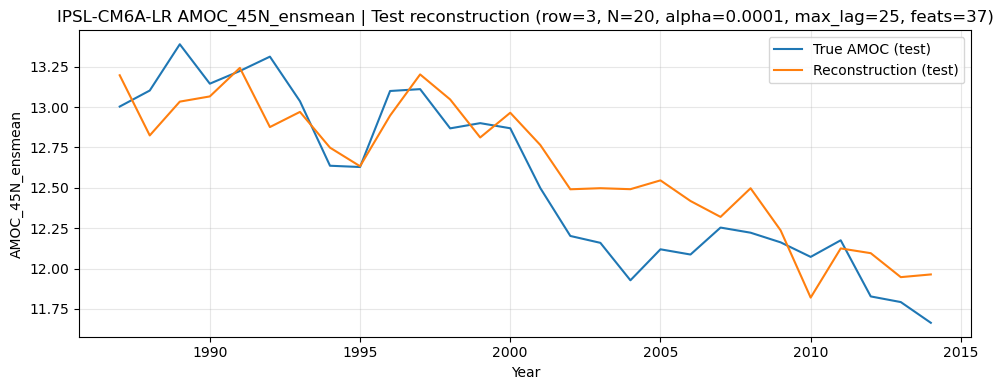

In [4]:
# ============================================================
# PLOT: choose run by row-index from the saved sweep metrics CSV
# ============================================================

import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# ----------------------------
# USER CHOICE
# ----------------------------
RUN_INDEX = 3   # 0-based index into the metrics CSV rows (e.g., 0->N=5, 1->N=10, 2->N=15, ...)
# If you want to override alpha manually, set this to a number; otherwise keep None
ALPHA_OVERRIDE = None

# ----------------------------
# Load sweep metrics + pick run
# ----------------------------
metrics_csv = out_csv  # produced earlier in your script
df_metrics = pd.read_csv(metrics_csv)

if RUN_INDEX < 0 or RUN_INDEX >= len(df_metrics):
    raise IndexError(f"RUN_INDEX={RUN_INDEX} out of range. metrics has {len(df_metrics)} rows (0..{len(df_metrics)-1}).")

run = df_metrics.iloc[int(RUN_INDEX)]
N_chosen = int(run["N_seeds"])
alpha_chosen = float(run["alpha"]) if ALPHA_OVERRIDE is None else float(ALPHA_OVERRIDE)

print("\nSelected run from metrics CSV:")
print(run.to_string())
print(f"\nUsing: N={N_chosen}, alpha={alpha_chosen}")

# ----------------------------
# Rebuild features + X/Y for chosen N
# ----------------------------
df_top = df_rank.head(N_chosen)
feats = build_selected_feature_set(df_top)

X, t_out, max_lag = build_X_from_features(pc_np, common_years, feats)
Y = AMOC[max_lag:]  # aligns with X rows

print(f"\nRebuilt from top-{N_chosen}: n_features={len(feats)}  computed max_lag={max_lag}")

# Compare with what was saved in the sweep metrics (helpful sanity check)
saved_max_lag = int(run["max_lag_used"])
saved_nfeat = int(run["n_features_after_window"])
if max_lag != saved_max_lag or len(feats) != saved_nfeat:
    print(f"⚠️ Note: rebuilt differs from saved sweep row:")
    print(f"   saved: n_features={saved_nfeat}, max_lag={saved_max_lag}")
    print(f"   now  : n_features={len(feats)}, max_lag={max_lag}")
    print("   This usually happens if LAG_WINDOW / CAP_LAGS_PER_GROUP / MAX_LAG_ALLOWED changed since you made the CSV.")

# ----------------------------
# Train/test split (same logic as sweep)
# ----------------------------
n_train = int((1 - TEST_FRAC) * len(X))
Xtr, Xte = X[:n_train], X[n_train:]
Ytr, Yte = Y[:n_train], Y[n_train:]
t_test = t_out[n_train:]

# ----------------------------
# Fit + predict
# ----------------------------
mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha_chosen))
mdl.fit(Xtr, Ytr)
pred = mdl.predict(Xte)

r2_t, r_t, var_t = metrics(Yte, pred)
print(f"\nTEST METRICS (selected run): R²={r2_t:.4f}  corr={r_t:.4f}  var={var_t:.3f}")

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(t_test, Yte, label="True AMOC (test)")
plt.plot(t_test, pred, label="Reconstruction (test)")
plt.xlabel("Year")
plt.ylabel(TARGET)  # you said this is already converted (Sv)
plt.title(
    f"{MODEL} {TARGET} | Test reconstruction (row={RUN_INDEX}, N={N_chosen}, alpha={alpha_chosen:g}, "
    f"max_lag={max_lag}, feats={len(feats)})"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_png = os.path.join(
    OUTDIR,
    f"{MODEL}_{TARGET}_test_recon_row{int(RUN_INDEX)}_N{N_chosen}_alpha{alpha_chosen:g}_lag{max_lag}.png"
)
plt.savefig(out_png, dpi=200)
print("Saved plot:", out_png)
plt.show()


In [5]:
#!/usr/bin/env python3
"""
RIDGE MODEL SELECTION WITH OPTION B:
TimeSeries CV inside TRAIN (first 80%), final TEST = last 20% (blocked)

Pipeline (leak-free w.r.t. final test):
  1) Build common year axis (1850–2014)
  2) Split years:
       TRAINVAL = first 80% (blocked)
       TEST     = last 20%  (blocked, untouched until the end)
  3) Inside TRAINVAL: TimeSeriesSplit (expanding window) to choose hyperparams:
       - N seeds (top-N ranked (var,lon,mode,lag))
       - lag window W (expand lag ±W)
       - ridge alpha
     IMPORTANT: feature ranking is recomputed inside each CV fold using ONLY fold-train
     (this avoids leakage from fold-validation into feature selection).
  4) Refit final model on full TRAINVAL using best (N,W,alpha) and TRAINVAL-only ranking
  5) Evaluate once on TEST (blocked last 20%)

Outputs in OUTDIR:
  - *_cv_grid_results.csv
  - *_best_params.txt
  - *_BEST_features.csv
  - *_final_test_metrics.csv
  - *_final_test_predictions.csv

Lag convention:
  lag >= 0 uses PC(t-lag) to predict AMOC(t)
"""

import os
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# CONFIG
# ============================================================

MODEL  = "IPSL-CM6A-LR"
TARGET = "AMOC_45N_ensmean"  # or "AMOC_26N_ensmean"

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES = 10

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

YEAR_START = 1850
YEAR_END   = 2014

TEST_FRAC = 0.20                 # final blocked test (last 20%)
N_SPLITS  = 5                    # TimeSeriesSplit folds inside TRAINVAL

# Lag search space for ranking
MAX_LAG_TOTAL = 50
MAX_LAG_ALLOWED = 25             # rank only lags 0..25 (recommended)

# Hyperparameter grids
N_LIST = [5, 10, 15, 20, 30, 40, 50]         # number of "seed" features
W_LIST = [0, 1, 2, 3]                        # lag-window expansion ±W
RIDGE_ALPHAS = [1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1000, 1e4, 1e5]

# Optional redundancy control after expansion
CAP_LAGS_PER_GROUP = None  # e.g. 5, or None to disable

OUTDIR = f"/data/users/frekle/AMOC_analysis/TopModeLagFeatures_new/{MODEL}/{TARGET}/RIDGE_OPTIONB_TSCV/"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def load_pc(var, lon_tag, n_modes):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))
    if "member" in PC.dims:
        PC = PC.mean("member")
    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)  # (year, mode)

def load_amoc_1d(target):
    dsA = xr.open_dataset(AMOC_FILE)
    am = dsA[target].squeeze()
    years = extract_years(am["time"])
    am = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    am = am.astype(float).squeeze()
    if am.ndim != 1:
        raise ValueError(f"AMOC target not 1D after squeeze: shape={am.shape}")
    return am  # (year,)

def corr_1d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return float(np.sum(aa * bb) / denom)

def rank_features_train_only(pc_np_sub, y_sub, lags_rank, vars_, lons_):
    """
    Build a DataFrame ranking features by |corr| using ONLY the provided subset arrays.
    pc_np_sub: dict[(var,lon)] -> np.ndarray shape (Tsub, modes)
    y_sub: np.ndarray shape (Tsub,)
    lags_rank: iterable of allowed non-negative lags
    """
    rows = []
    Tsub = len(y_sub)
    for var in vars_:
        for lon in lons_:
            pc = pc_np_sub[(var, lon)]  # (Tsub, M)
            for lag in lags_rank:
                lag = int(lag)
                if lag >= Tsub:
                    continue
                t_idx = np.arange(lag, Tsub)
                p_idx = t_idx - lag
                yy = y_sub[t_idx]
                for m in range(pc.shape[1]):
                    pp = pc[p_idx, m]
                    c = corr_1d(pp, yy)
                    if np.isfinite(c):
                        rows.append({
                            "var": var,
                            "lon": lon,
                            "mode": int(m + 1),   # 1-based
                            "lag": int(lag),
                            "corr": float(c),
                            "abs_corr": float(abs(c)),
                        })
    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise RuntimeError("No finite correlations computed in ranking step.")
    df = df.sort_values("abs_corr", ascending=False).reset_index(drop=True)
    return df

def build_selected_feature_set(df_ranked, N_seeds, W, max_lag_allowed, cap_lags_per_group=None):
    """
    Take top-N seeds from df_ranked and expand each lag into window ±W.
    Returns list of (var, lon, mode0, lag) unique + sorted.
    """
    df_top = df_ranked.head(int(N_seeds))

    seeds = []
    for _, row in df_top.iterrows():
        var = str(row["var"])
        lon = str(row["lon"])
        mode1 = int(row["mode"])      # 1-based
        lag = int(row["lag"])
        seeds.append((var, lon, mode1 - 1, lag))  # mode0

    expanded = []
    for (var, lon, m0, lag0) in seeds:
        for L in range(lag0 - int(W), lag0 + int(W) + 1):
            if L < 0:
                continue
            if max_lag_allowed is not None and L > int(max_lag_allowed):
                continue
            expanded.append((var, lon, m0, int(L)))

    if cap_lags_per_group is not None:
        keep = []
        seen = {}
        for feat in expanded:
            key = (feat[0], feat[1], feat[2])  # (var,lon,mode0)
            seen.setdefault(key, set())
            if feat[3] not in seen[key]:
                if len(seen[key]) < int(cap_lags_per_group):
                    seen[key].add(feat[3])
                    keep.append(feat)
        expanded = keep

    feats = sorted(set(expanded), key=lambda x: (x[0], x[1], x[2], x[3]))
    return feats

def build_XY_for_segment(pc_np_full, y_full, feats, t_positions):
    """
    Build X,Y for a contiguous segment indexed by t_positions (positions into FULL arrays).
    We construct rows for t in t_positions where t >= max_lag.
    Each feature uses pc[t-lag, mode].

    pc_np_full: dict[(var,lon)] -> np.ndarray (Tfull, modes)
    y_full: np.ndarray (Tfull,)
    feats: list (var,lon,mode0,lag)
    t_positions: np.ndarray of int positions (e.g. fold train indices into TRAINVAL arrays)
                 NOTE: these are positions relative to FULL arrays used here.

    Returns: X, Y, t_used_positions, max_lag
    """
    t_positions = np.asarray(t_positions, dtype=int)
    if len(feats) == 0:
        raise ValueError("Empty feature set.")

    max_lag = max(lag for (_, _, _, lag) in feats)
    # only positions that have enough history
    t_used = t_positions[t_positions >= max_lag]
    if len(t_used) == 0:
        return np.empty((0, len(feats))), np.empty((0,)), t_used, max_lag

    X = np.empty((len(t_used), len(feats)), dtype=float)
    for i, t in enumerate(t_used):
        for j, (var, lon, m0, lag) in enumerate(feats):
            X[i, j] = pc_np_full[(var, lon)][t - lag, m0]
    Y = y_full[t_used]
    return X, Y, t_used, int(max_lag)

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan
    r = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    return r2, r, var_ratio

# ============================================================
# LOAD DATA + ALIGN YEARS
# ============================================================

print("Loading EOF PCs...")
pc_dict = {}
for var in VARS:
    for lon in LON_TAGS:
        pc_dict[(var, lon)] = load_pc(var, lon, N_MODES)
        print(f"  ✓ {var} {lon} PC: {tuple(pc_dict[(var, lon)].shape)}")

print("Loading AMOC...")
AMOC_da = load_amoc_1d(TARGET)

# common years across all
common_years = AMOC_da["year"].values.astype(int)
for da in pc_dict.values():
    common_years = np.intersect1d(common_years, da["year"].values.astype(int))
common_years = np.asarray(common_years).astype(int)
common_years.sort()

# enforce fixed range
common_years = common_years[(common_years >= YEAR_START) & (common_years <= YEAR_END)]
if len(common_years) < 30:
    raise RuntimeError("Too few years after applying YEAR_START/YEAR_END.")

# Pull arrays on common years
y_full = AMOC_da.sel(year=common_years).values.astype(float).squeeze()
pc_np_full = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}  # (T, mode)

T = len(common_years)
n_test = int(np.ceil(TEST_FRAC * T))
n_trainval = T - n_test

trainval_years = common_years[:n_trainval]
test_years = common_years[n_trainval:]

print(f"\n✓ YEARS total: {common_years[0]}–{common_years[-1]} (T={T})")
print(f"✓ TRAINVAL (80%): {trainval_years[0]}–{trainval_years[-1]} (T={len(trainval_years)})")
print(f"✓ TEST (20%):     {test_years[0]}–{test_years[-1]} (T={len(test_years)})")

# Indices into FULL arrays
idx_trainval = np.arange(0, n_trainval, dtype=int)
idx_test = np.arange(n_trainval, T, dtype=int)

# Lags used for ranking
LAGS = np.arange(0, MAX_LAG_TOTAL, 1, dtype=int)
if MAX_LAG_ALLOWED is not None:
    if MAX_LAG_ALLOWED >= MAX_LAG_TOTAL:
        raise ValueError("MAX_LAG_ALLOWED must be < MAX_LAG_TOTAL")
    LAGS_RANK = LAGS[LAGS <= int(MAX_LAG_ALLOWED)]
else:
    LAGS_RANK = LAGS

# ============================================================
# OPTION B: TimeSeriesSplit inside TRAINVAL
#   - ranking recomputed inside each fold using fold-train only
# ============================================================

tscv = TimeSeriesSplit(n_splits=int(N_SPLITS))

grid_rows = []

print("\nRunning TimeSeriesSplit CV on TRAINVAL...")
for N_seeds in N_LIST:
    for W in W_LIST:
        for alpha in RIDGE_ALPHAS:

            fold_r2 = []
            fold_corr = []
            fold_var = []
            fold_nfeats = []
            fold_maxlag = []

            for fold_id, (tr_rel, va_rel) in enumerate(tscv.split(idx_trainval), start=1):
                # Map fold indices (relative to TRAINVAL) into FULL indices
                tr_idx = idx_trainval[tr_rel]   # always starts at 0, expanding
                va_idx = idx_trainval[va_rel]

                # ---- build fold-train-only arrays for ranking ----
                y_tr = y_full[tr_idx]
                pc_tr = {(var, lon): pc_np_full[(var, lon)][tr_idx, :] for var in VARS for lon in LON_TAGS}

                # ---- rank features on fold-train ONLY (prevents leakage) ----
                df_rank = rank_features_train_only(pc_tr, y_tr, LAGS_RANK, VARS, LON_TAGS)

                # ---- build feature set for this (N_seeds, W) ----
                feats = build_selected_feature_set(
                    df_ranked=df_rank,
                    N_seeds=N_seeds,
                    W=W,
                    max_lag_allowed=MAX_LAG_ALLOWED,
                    cap_lags_per_group=CAP_LAGS_PER_GROUP
                )

                # ---- build X/Y for train + val using FULL arrays (still leak-free) ----
                Xtr, Ytr, tr_used, maxlag = build_XY_for_segment(pc_np_full, y_full, feats, tr_idx)
                Xva, Yva, va_used, _      = build_XY_for_segment(pc_np_full, y_full, feats, va_idx)

                # If fold too small after lag trimming, skip
                if len(Ytr) < 10 or len(Yva) < 5:
                    continue

                mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha)))
                mdl.fit(Xtr, Ytr)
                pred_va = mdl.predict(Xva)

                r2, r, vr = metrics(Yva, pred_va)
                fold_r2.append(r2)
                fold_corr.append(r)
                fold_var.append(vr)
                fold_nfeats.append(len(feats))
                fold_maxlag.append(maxlag)

            if len(fold_r2) == 0:
                continue

            grid_rows.append({
                "N_seeds": int(N_seeds),
                "W": int(W),
                "alpha": float(alpha),
                "mean_val_r2": float(np.nanmean(fold_r2)),
                "std_val_r2": float(np.nanstd(fold_r2)),
                "mean_val_corr": float(np.nanmean(fold_corr)),
                "mean_val_var_ratio": float(np.nanmean(fold_var)),
                "mean_n_features": float(np.mean(fold_nfeats)),
                "mean_max_lag": float(np.mean(fold_maxlag)),
                "n_folds_used": int(len(fold_r2)),
            })

            print(f"  N={N_seeds:2d} W={W} alpha={alpha:<8g} | "
                  f"val R²={np.nanmean(fold_r2): .4f} ±{np.nanstd(fold_r2):.4f} "
                  f"(folds={len(fold_r2)})")

df_grid = pd.DataFrame(grid_rows)
if len(df_grid) == 0:
    raise RuntimeError("CV grid produced no results (check splits / lag constraints).")

# pick best by mean validation R2
df_grid = df_grid.sort_values(["mean_val_r2", "std_val_r2"], ascending=[False, True]).reset_index(drop=True)
best = df_grid.iloc[0].to_dict()

out_grid = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_cv_grid_results.csv")
df_grid.to_csv(out_grid, index=False)
print("\nSaved CV grid results:", out_grid)

best_txt = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_best_params.txt")
with open(best_txt, "w") as f:
    for k, v in best.items():
        f.write(f"{k}: {v}\n")
print("Saved best params:", best_txt)

print("\n✓ BEST (by mean validation R²):")
print(best)

# ============================================================
# REFIT FINAL MODEL ON FULL TRAINVAL USING BEST PARAMS
#   - rank features on FULL TRAINVAL (still not using TEST)
# ============================================================

print("\nRefitting final model on full TRAINVAL...")

# rank using full TRAINVAL only
y_trainval = y_full[idx_trainval]
pc_trainval = {(var, lon): pc_np_full[(var, lon)][idx_trainval, :] for var in VARS for lon in LON_TAGS}
df_rank_tv = rank_features_train_only(pc_trainval, y_trainval, LAGS_RANK, VARS, LON_TAGS)

feats_final = build_selected_feature_set(
    df_ranked=df_rank_tv,
    N_seeds=int(best["N_seeds"]),
    W=int(best["W"]),
    max_lag_allowed=MAX_LAG_ALLOWED,
    cap_lags_per_group=CAP_LAGS_PER_GROUP
)

# save final feature list
feat_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_BEST_features.csv")
pd.DataFrame(feats_final, columns=["var", "lon", "mode0", "lag"]).to_csv(feat_csv, index=False)
print("Saved final feature set:", feat_csv)

# build trainval design
X_tv, Y_tv, tv_used, maxlag_final = build_XY_for_segment(pc_np_full, y_full, feats_final, idx_trainval)

# fit final model
final_alpha = float(best["alpha"])
final_model = make_pipeline(StandardScaler(), Ridge(alpha=final_alpha))
final_model.fit(X_tv, Y_tv)

# ============================================================
# FINAL EVALUATION ON HELD-OUT TEST BLOCK (ONE SHOT)
# ============================================================

print("\nEvaluating once on final TEST block...")

X_te, Y_te, te_used, _ = build_XY_for_segment(pc_np_full, y_full, feats_final, idx_test)

pred_te = final_model.predict(X_te)
test_r2, test_corr, test_var = metrics(Y_te, pred_te)

print(f"✓ FINAL TEST metrics (years {test_years[0]}–{test_years[-1]}):")
print(f"  R²       = {test_r2: .4f}")
print(f"  corr     = {test_corr: .4f}")
print(f"  var_ratio= {test_var: .3f}")
print(f"  max_lag  = {maxlag_final}")
print(f"  n_feats  = {len(feats_final)}")

# save test metrics
met_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_final_test_metrics.csv")
pd.DataFrame([{
    "model": MODEL,
    "target": TARGET,
    "year_start": int(common_years[0]),
    "year_end": int(common_years[-1]),
    "trainval_start": int(trainval_years[0]),
    "trainval_end": int(trainval_years[-1]),
    "test_start": int(test_years[0]),
    "test_end": int(test_years[-1]),
    "TEST_FRAC": float(TEST_FRAC),
    "N_SPLITS": int(N_SPLITS),
    "best_N_seeds": int(best["N_seeds"]),
    "best_W": int(best["W"]),
    "best_alpha": float(best["alpha"]),
    "max_lag_used": int(maxlag_final),
    "n_features_used": int(len(feats_final)),
    "test_r2": float(test_r2),
    "test_corr": float(test_corr),
    "test_var_ratio": float(test_var),
}]).to_csv(met_csv, index=False)
print("Saved final test metrics:", met_csv)

# save predictions for plotting
pred_csv = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_final_test_predictions.csv")
pd.DataFrame({
    "year": common_years[te_used],
    "y_true": Y_te,
    "y_pred": pred_te,
}).to_csv(pred_csv, index=False)
print("Saved final test predictions:", pred_csv)

print("\n✅ DONE (Option B: CV inside trainval, final evaluation on held-out test).")


Loading EOF PCs...
  ✓ thetao W10p0 PC: (165, 10)
  ✓ thetao W20p0 PC: (165, 10)
  ✓ thetao W30p0 PC: (165, 10)
  ✓ thetao W40p0 PC: (165, 10)
  ✓ thetao W60p0 PC: (165, 10)
  ✓ so W10p0 PC: (165, 10)
  ✓ so W20p0 PC: (165, 10)
  ✓ so W30p0 PC: (165, 10)
  ✓ so W40p0 PC: (165, 10)
  ✓ so W60p0 PC: (165, 10)
Loading AMOC...

✓ YEARS total: 1850–2014 (T=165)
✓ TRAINVAL (80%): 1850–1981 (T=132)
✓ TEST (20%):     1982–2014 (T=33)

Running TimeSeriesSplit CV on TRAINVAL...
  N= 5 W=0 alpha=0.0001   | val R²=-2.4728 ±2.9153 (folds=4)
  N= 5 W=0 alpha=0.001    | val R²=-2.4717 ±2.9134 (folds=4)
  N= 5 W=0 alpha=0.01     | val R²=-2.4598 ±2.8937 (folds=4)
  N= 5 W=0 alpha=0.1      | val R²=-2.3476 ±2.7080 (folds=4)
  N= 5 W=0 alpha=1        | val R²=-1.6488 ±1.5874 (folds=4)
  N= 5 W=0 alpha=10       | val R²=-0.7259 ±0.4794 (folds=4)
  N= 5 W=0 alpha=100      | val R²=-0.5935 ±0.6455 (folds=4)
  N= 5 W=0 alpha=1000     | val R²=-1.3567 ±1.8024 (folds=4)
  N= 5 W=0 alpha=10000    | val R²=-1.7

### With new goal

In [ ]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION + ROBUST FEATURE DISCOVERY PIPELINE (PRODUCTION)
===================================================================

Goal:
  - Reconstruct AMOC with as few interpretable features as possible
  - Choose hyperparameters using time-series CV inside train (no test leakage)
  - Identify "robust" predictors via stability selection across members
  - Optionally compute early-warning metrics (lag-1 AC, variance) on selected PCs

Supports:
  ✅ Any model with:
      - EOF_latdepth_<var>_<lon>.nc containing PC(member?, time, mode)
      - AMOC_<MODEL>.nc containing AMOC_26N_* and/or AMOC_45N_* (ensmean and member)
  ✅ Run on ensemble-mean OR member-by-member (choose)
  ✅ Final test block is last 20% of years (blocked, never used in CV/ranking)

Key design choices (thesis-defensible):
  - Feature ranking (corr across lags) is done ONLY on fold-train (inside CV)
  - Hyperparameters (N_seeds, W, alpha) chosen by mean CV validation R²
  - "Parsimonious model": choose smallest within 1σ of best CV score (optional)
  - Stability selection: keep only features appearing in ≥freq threshold across members

Outputs (in OUTDIR/<MODEL>/<TARGET>/):
  - cv_grid_results_*.csv
  - best_params_*.txt
  - best_features_*.csv
  - (member mode) member_best_features_*.csv, stability_features_*.csv
  - final_test_metrics_*.csv, final_test_predictions_*.csv
  - (optional) ews_metrics_*.csv

-------------------------------------------------------------------
USAGE EXAMPLES
-------------------------------------------------------------------

1) Ensemble mean, single model:
  python amoc_pipeline.py --model IPSL-CM6A-LR --target AMOC_45N_ensmean --mode ensmean

2) Member-by-member stability selection:
  python amoc_pipeline.py --model IPSL-CM6A-LR --target AMOC_45N_member --mode member \
      --members 0 1 2 3 4 --freq_thresh 0.6

3) All models in a list:
  python amoc_pipeline.py --models IPSL-CM6A-LR CESM2 MPI-ESM1-2-LR --target AMOC_45N_ensmean --mode ensmean

4) Turn on EWS computation for selected predictors:
  python amoc_pipeline.py --model IPSL-CM6A-LR --target AMOC_45N_member --mode member \
      --members 0 1 2 3 4 --compute_ews 1 --ews_window 31 --ews_detrend 1

-------------------------------------------------------------------
NOTES
-------------------------------------------------------------------
- If your AMOC file uses different variable names, adjust load_amoc().
- If your EOF files store time as 'year' already, this still works.
"""

import os
import argparse
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score


# ============================================================
# I/O HELPERS
# ============================================================

def extract_years(time_coord):
    """Robust year extraction for cftime/numpy datetime or string-like."""
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)


def load_pc(EOF_DIR, var, lon_tag, n_modes, member_mode=False, member_id=None):
    """
    Loads PC from EOF_latdepth_<var>_<lon>.nc
      PC dims: (member?, time, mode) or (time, mode)
    Returns DataArray (year, mode) for ensmean OR (year, mode) for one member.
    """
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))

    if "member" in PC.dims:
        if member_mode:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")
            PC = PC.sel(member=member_id)
        else:
            PC = PC.mean("member")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)  # (year, mode)


def load_amoc(AMOC_FILE, target, member_mode=False, member_id=None):
    """
    Loads AMOC target from AMOC_<MODEL>.nc.

    Expected possibilities (you can adapt to your own file):
      - AMOC_45N_ensmean(year)
      - AMOC_45N_member(member, year/time)

    This function returns 1D DataArray (year,) for a chosen member or ensmean.
    """
    dsA = xr.open_dataset(AMOC_FILE)
    if target not in dsA.variables:
        raise KeyError(f"Target '{target}' not found in {AMOC_FILE}. Available: {list(dsA.variables)}")

    am = dsA[target].squeeze()

    if "member" in am.dims:
        if not member_mode:
            # if user asked ensmean but file is member-only, take mean
            am = am.mean("member")
        else:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")
            am = am.sel(member=member_id)

    # to year axis
    if "year" in am.dims:
        am_year = am
        if "time" in am_year.coords:
            am_year = am_year.drop_vars("time")
    else:
        years = extract_years(am["time"])
        am_year = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    am_year = am_year.astype(float).squeeze()
    if am_year.ndim != 1:
        raise ValueError(f"AMOC target not 1D after selection: shape={am_year.shape}")

    return am_year  # (year,)


# ============================================================
# MATH HELPERS
# ============================================================

def corr_1d(a, b):
    """Pearson correlation with NaN handling."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return float(np.sum(aa * bb) / denom)


def rank_features_train_only(pc_np_sub, y_sub, vars_, lons_, n_modes, lags_rank):
    """
    Rank features by |corr| using ONLY the provided subset arrays.

    pc_np_sub: dict[(var,lon)] -> np.ndarray (Tsub, n_modes)
    y_sub: np.ndarray (Tsub,)
    returns: DataFrame sorted by abs_corr desc with columns: var, lon, mode(1-based), lag, corr, abs_corr
    """
    rows = []
    Tsub = len(y_sub)
    for var in vars_:
        for lon in lons_:
            pc = pc_np_sub[(var, lon)]  # (Tsub, modes)
            for lag in lags_rank:
                lag = int(lag)
                if lag >= Tsub:
                    continue
                t_idx = np.arange(lag, Tsub)
                p_idx = t_idx - lag
                yy = y_sub[t_idx]
                for m in range(n_modes):
                    pp = pc[p_idx, m]
                    c = corr_1d(pp, yy)
                    if np.isfinite(c):
                        rows.append({
                            "var": var,
                            "lon": lon,
                            "mode": int(m + 1),
                            "lag": int(lag),
                            "corr": float(c),
                            "abs_corr": float(abs(c)),
                        })
    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise RuntimeError("No finite correlations computed in ranking step.")
    return df.sort_values("abs_corr", ascending=False).reset_index(drop=True)


def build_feature_set(df_ranked, n_seeds, W, max_lag_allowed, cap_lags_per_group=None):
    """
    Take top n_seeds from df_ranked and expand lag±W.
    Returns sorted unique list of (var, lon, mode0, lag).
    """
    df_top = df_ranked.head(int(n_seeds))

    seeds = []
    for _, row in df_top.iterrows():
        seeds.append((str(row["var"]), str(row["lon"]), int(row["mode"]) - 1, int(row["lag"])))

    expanded = []
    for (var, lon, m0, lag0) in seeds:
        for L in range(lag0 - int(W), lag0 + int(W) + 1):
            if L < 0:
                continue
            if max_lag_allowed is not None and L > int(max_lag_allowed):
                continue
            expanded.append((var, lon, m0, int(L)))

    if cap_lags_per_group is not None:
        keep = []
        seen = {}
        for feat in expanded:
            key = (feat[0], feat[1], feat[2])  # (var,lon,mode0)
            seen.setdefault(key, set())
            if feat[3] not in seen[key]:
                if len(seen[key]) < int(cap_lags_per_group):
                    seen[key].add(feat[3])
                    keep.append(feat)
        expanded = keep

    return sorted(set(expanded), key=lambda x: (x[0], x[1], x[2], x[3]))


def build_XY(pc_np_full, y_full, feats, t_positions):
    """
    Build X,Y using features with lags.
    pc_np_full: dict[(var,lon)] -> np.ndarray (T, n_modes)
    y_full: np.ndarray (T,)
    feats: list (var, lon, mode0, lag)
    t_positions: indices into full arrays
    Returns (X, Y, t_used, max_lag)
    """
    t_positions = np.asarray(t_positions, dtype=int)
    if len(feats) == 0:
        raise ValueError("Empty feature set.")

    max_lag = max(lag for (_, _, _, lag) in feats)
    t_used = t_positions[t_positions >= max_lag]
    if len(t_used) == 0:
        return np.empty((0, len(feats))), np.empty((0,)), t_used, int(max_lag)

    X = np.empty((len(t_used), len(feats)), dtype=float)
    for i, t in enumerate(t_used):
        for j, (var, lon, m0, lag) in enumerate(feats):
            X[i, j] = pc_np_full[(var, lon)][t - lag, m0]
    Y = y_full[t_used]
    return X, Y, t_used, int(max_lag)


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan
    r = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    return r2, r, var_ratio


def make_gap_folds(T_trainval, n_splits, gap):
    """
    Create expanding-window folds with a "gap/embargo" between train and val.
    This helps when using lagged predictors.

    Returns list of (train_idx, val_idx) indices relative to trainval (0..T_trainval-1).
    """
    tscv = TimeSeriesSplit(n_splits=int(n_splits))
    folds = []
    base = np.arange(T_trainval, dtype=int)
    for tr, va in tscv.split(base):
        # embargo: remove last 'gap' points from train to avoid dependence near boundary
        if gap is not None and gap > 0:
            if len(tr) <= gap:
                continue
            tr2 = tr[:-int(gap)]
        else:
            tr2 = tr
        if len(tr2) < 20 or len(va) < 10:
            continue
        folds.append((tr2, va))
    return folds


def one_se_rule_choose(df_grid, score_col="mean_val_r2", std_col="std_val_r2"):
    """
    Choose the simplest model within 1 standard deviation of the best mean score.
    "Simplest" = smaller N_seeds, smaller W, larger alpha (more regularization).
    """
    best = df_grid.iloc[0]
    threshold = best[score_col] - best[std_col]

    df_ok = df_grid[df_grid[score_col] >= threshold].copy()
    if len(df_ok) == 0:
        return best.to_dict()

    # "simplicity" ordering
    df_ok = df_ok.sort_values(
        by=["N_seeds", "W", "alpha"],
        ascending=[True, True, False]
    ).reset_index(drop=True)
    return df_ok.iloc[0].to_dict()


# ============================================================
# EWS (OPTIONAL)
# ============================================================

def rolling_detrend(y):
    """
    Remove linear trend from a 1D array y using least squares.
    """
    y = np.asarray(y, float)
    x = np.arange(len(y), dtype=float)
    m = np.isfinite(y)
    if m.sum() < 5:
        return y * np.nan
    X = np.vstack([x[m], np.ones(m.sum())]).T
    beta, *_ = np.linalg.lstsq(X, y[m], rcond=None)
    trend = beta[0] * x + beta[1]
    out = y.copy()
    out[m] = y[m] - trend[m]
    return out


def compute_ews_series(x, years, window=31, detrend=True):
    """
    Compute rolling lag-1 autocorrelation and variance.
    Returns DataFrame with center_year, ac1, var.

    Important: EWS on raw trending series can be biased -> detrend=True recommended.
    """
    x = np.asarray(x, float)
    years = np.asarray(years, int)
    half = window // 2
    rows = []
    for i in range(half, len(x) - half):
        seg = x[i - half:i + half + 1]
        seg = seg[np.isfinite(seg)]
        if len(seg) < max(10, window // 2):
            continue
        if detrend:
            seg = rolling_detrend(seg)
            seg = seg[np.isfinite(seg)]
            if len(seg) < max(10, window // 2):
                continue

        # lag-1 AC
        a = seg[:-1]
        b = seg[1:]
        ac1 = corr_1d(a, b)

        # variance
        vv = float(np.var(seg, ddof=1)) if len(seg) > 2 else np.nan

        rows.append({"center_year": int(years[i]), "ac1": float(ac1), "var": vv})
    return pd.DataFrame(rows)


# ============================================================
# CORE PIPELINE (ONE RUN: ONE MODEL + ONE TARGET + ONE DATASET)
# ============================================================

def run_one(model, target, mode, cfg):
    """
    mode: 'ensmean' or 'member'
    For member mode, cfg['member_id'] must be set.
    """
    EOF_DIR = cfg["EOF_DIR_TEMPLATE"].format(MODEL=model)
    AMOC_FILE = cfg["AMOC_FILE_TEMPLATE"].format(MODEL=model)

    # --- load PCs ---
    pc_dict = {}
    for var in cfg["VARS"]:
        for lon in cfg["LON_TAGS"]:
            pc_dict[(var, lon)] = load_pc(
                EOF_DIR, var, lon, cfg["N_MODES"],
                member_mode=(mode == "member"),
                member_id=cfg.get("member_id")
            )

    # --- load AMOC ---
    am = load_amoc(
        AMOC_FILE, target,
        member_mode=(mode == "member"),
        member_id=cfg.get("member_id")
    )

    # --- align years ---
    common_years = am["year"].values.astype(int)
    for da in pc_dict.values():
        common_years = np.intersect1d(common_years, da["year"].values.astype(int))
    common_years = np.asarray(common_years, int)
    common_years.sort()

    # enforce range
    y0, y1 = cfg["YEAR_START"], cfg["YEAR_END"]
    common_years = common_years[(common_years >= y0) & (common_years <= y1)]
    if len(common_years) < 50:
        raise RuntimeError(f"Too few years after applying {y0}–{y1}: T={len(common_years)}")

    y_full = am.sel(year=common_years).values.astype(float).squeeze()
    pc_np_full = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}  # (T, mode)

    # split trainval/test (blocked last 20%)
    T = len(common_years)
    n_test = int(np.ceil(cfg["TEST_FRAC"] * T))
    n_trainval = T - n_test

    idx_trainval = np.arange(0, n_trainval, dtype=int)
    idx_test = np.arange(n_trainval, T, dtype=int)

    trainval_years = common_years[:n_trainval]
    test_years = common_years[n_trainval:]

    # lags for ranking
    max_lag_total = cfg["MAX_LAG_TOTAL"]
    max_lag_allowed = cfg["MAX_LAG_ALLOWED"]
    lags = np.arange(0, max_lag_total, dtype=int)
    if max_lag_allowed is not None:
        lags = lags[lags <= int(max_lag_allowed)]

    # folds with gap
    gap = cfg["GAP_EMBARGO"]
    folds = make_gap_folds(len(idx_trainval), cfg["N_SPLITS"], gap)
    if len(folds) < 2:
        raise RuntimeError("Not enough folds after applying gap/size constraints. Reduce GAP or N_SPLITS.")

    # grid search with fold-train ranking (no leakage)
    grid_rows = []
    for N_seeds in cfg["N_LIST"]:
        for W in cfg["W_LIST"]:
            for alpha in cfg["RIDGE_ALPHAS"]:
                fold_r2, fold_corr, fold_var = [], [], []
                fold_nfeat, fold_maxlag = [], []

                for (tr_rel, va_rel) in folds:
                    tr_idx = idx_trainval[tr_rel]
                    va_idx = idx_trainval[va_rel]

                    # ranking uses only fold-train
                    y_tr = y_full[tr_idx]
                    pc_tr = {(var, lon): pc_np_full[(var, lon)][tr_idx, :] for var in cfg["VARS"] for lon in cfg["LON_TAGS"]}
                    df_rank = rank_features_train_only(pc_tr, y_tr, cfg["VARS"], cfg["LON_TAGS"], cfg["N_MODES"], lags)

                    feats = build_feature_set(
                        df_ranked=df_rank,
                        n_seeds=N_seeds,
                        W=W,
                        max_lag_allowed=max_lag_allowed,
                        cap_lags_per_group=cfg["CAP_LAGS_PER_GROUP"]
                    )

                    Xtr, Ytr, _, maxlag = build_XY(pc_np_full, y_full, feats, tr_idx)
                    Xva, Yva, _, _      = build_XY(pc_np_full, y_full, feats, va_idx)

                    if len(Ytr) < 20 or len(Yva) < 10:
                        continue

                    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha)))
                    mdl.fit(Xtr, Ytr)
                    pred = mdl.predict(Xva)

                    r2, r, vr = metrics(Yva, pred)
                    fold_r2.append(r2)
                    fold_corr.append(r)
                    fold_var.append(vr)
                    fold_nfeat.append(len(feats))
                    fold_maxlag.append(maxlag)

                if len(fold_r2) < max(2, len(folds) - 1):
                    continue

                grid_rows.append({
                    "model": model,
                    "target": target,
                    "mode": mode,
                    "member_id": cfg.get("member_id", np.nan),
                    "N_seeds": int(N_seeds),
                    "W": int(W),
                    "alpha": float(alpha),
                    "mean_val_r2": float(np.nanmean(fold_r2)),
                    "std_val_r2": float(np.nanstd(fold_r2)),
                    "mean_val_corr": float(np.nanmean(fold_corr)),
                    "mean_val_var_ratio": float(np.nanmean(fold_var)),
                    "mean_n_features": float(np.mean(fold_nfeat)),
                    "mean_max_lag": float(np.mean(fold_maxlag)),
                    "n_folds_used": int(len(fold_r2)),
                })

    df_grid = pd.DataFrame(grid_rows)
    if len(df_grid) == 0:
        raise RuntimeError("No CV results (grid too strict / folds too small).")

    # sort by best validation R²
    df_grid = df_grid.sort_values(["mean_val_r2", "std_val_r2"], ascending=[False, True]).reset_index(drop=True)

    # choose best params (optionally 1-SE rule for parsimony)
    if cfg["USE_ONE_SE_RULE"]:
        best = one_se_rule_choose(df_grid)
        best_tag = "best_1se"
    else:
        best = df_grid.iloc[0].to_dict()
        best_tag = "best"

    # final feature ranking on full trainval only (still no test)
    y_tv = y_full[idx_trainval]
    pc_tv = {(var, lon): pc_np_full[(var, lon)][idx_trainval, :] for var in cfg["VARS"] for lon in cfg["LON_TAGS"]}
    df_rank_tv = rank_features_train_only(pc_tv, y_tv, cfg["VARS"], cfg["LON_TAGS"], cfg["N_MODES"], lags)

    feats_final = build_feature_set(
        df_ranked=df_rank_tv,
        n_seeds=int(best["N_seeds"]),
        W=int(best["W"]),
        max_lag_allowed=max_lag_allowed,
        cap_lags_per_group=cfg["CAP_LAGS_PER_GROUP"]
    )

    # fit final model on full trainval
    X_tv, Y_tv, tv_used, maxlag_final = build_XY(pc_np_full, y_full, feats_final, idx_trainval)
    final_model = make_pipeline(StandardScaler(), Ridge(alpha=float(best["alpha"])))
    final_model.fit(X_tv, Y_tv)

    # evaluate once on test
    X_te, Y_te, te_used, _ = build_XY(pc_np_full, y_full, feats_final, idx_test)
    pred_te = final_model.predict(X_te)
    test_r2, test_corr, test_var = metrics(Y_te, pred_te)

    result = {
        "df_grid": df_grid,
        "best": best,
        "best_tag": best_tag,
        "feats_final": feats_final,
        "years": common_years,
        "trainval_years": trainval_years,
        "test_years": test_years,
        "test_metrics": {
            "test_r2": test_r2,
            "test_corr": test_corr,
            "test_var_ratio": test_var,
            "max_lag_used": maxlag_final,
            "n_features_used": len(feats_final),
        },
        "test_pred_df": pd.DataFrame({
            "year": common_years[te_used],
            "y_true": Y_te,
            "y_pred": pred_te
        })
    }

    # optional EWS on selected PC series (unlagged)
    if cfg["COMPUTE_EWS"]:
        ews_rows = []
        # build series for each unique (var,lon,mode0) in final features
        uniq = sorted(set((v, l, m0) for (v, l, m0, _) in feats_final))
        for (v, l, m0) in uniq:
            series = pc_np_full[(v, l)][:, m0]
            df_ews = compute_ews_series(series, common_years, window=cfg["EWS_WINDOW"], detrend=cfg["EWS_DETREND"])
            df_ews["model"] = model
            df_ews["target"] = target
            df_ews["mode"] = int(m0 + 1)
            df_ews["var"] = v
            df_ews["lon"] = l
            df_ews["mode_key"] = f"{v}_{l}_m{m0+1}"
            ews_rows.append(df_ews)
        result["ews_df"] = pd.concat(ews_rows, ignore_index=True) if len(ews_rows) else pd.DataFrame()

    return result


# ============================================================
# STABILITY SELECTION ACROSS MEMBERS
# ============================================================

def stability_selection(member_results, freq_thresh=0.6):
    """
    member_results: list of dict results from run_one() in member mode.
    Returns:
      - df_member_features: long table of features per member
      - df_stable: stable features with frequency >= freq_thresh
    """
    all_rows = []
    for res in member_results:
        mid = res["best"].get("member_id", np.nan)
        for (var, lon, m0, lag) in res["feats_final"]:
            all_rows.append({
                "member_id": int(mid) if np.isfinite(mid) else mid,
                "var": var,
                "lon": lon,
                "mode0": int(m0),
                "mode": int(m0 + 1),
                "lag": int(lag),
                "feature_key": f"{var}|{lon}|m{m0}|lag{lag}"
            })
    df = pd.DataFrame(all_rows)
    if len(df) == 0:
        return df, pd.DataFrame()

    counts = df.groupby(["var", "lon", "mode0", "lag", "feature_key"]).size().reset_index(name="count")
    n_members = df["member_id"].nunique()
    counts["freq"] = counts["count"] / float(n_members)

    df_stable = counts[counts["freq"] >= float(freq_thresh)].copy()
    df_stable = df_stable.sort_values(["freq", "count"], ascending=[False, False]).reset_index(drop=True)

    return df, df_stable


# ============================================================
# MAIN
# ============================================================

def parse_args():
    ap = argparse.ArgumentParser()
    ap.add_argument("--model", default=None, help="Single model name (e.g. IPSL-CM6A-LR)")
    ap.add_argument("--models", nargs="*", default=None, help="List of models (overrides --model)")
    ap.add_argument("--target", required=True, help="AMOC variable name in AMOC_<MODEL>.nc, e.g. AMOC_45N_ensmean or AMOC_45N_member")
    ap.add_argument("--mode", choices=["ensmean", "member"], required=True, help="Run on ensmean or member-by-member")
    ap.add_argument("--members", nargs="*", type=int, default=None, help="Member IDs to run (member mode only). If omitted, tries 0..9")
    ap.add_argument("--freq_thresh", type=float, default=0.6, help="Stability selection frequency threshold across members")

    # core paths (edit if needed)
    ap.add_argument("--eof_dir_template", default="/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/")
    ap.add_argument("--amoc_file_template", default="/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc")
    ap.add_argument("--out_root", default="/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS/")

    # time + split
    ap.add_argument("--year_start", type=int, default=1850)
    ap.add_argument("--year_end", type=int, default=2014)
    ap.add_argument("--test_frac", type=float, default=0.20)
    ap.add_argument("--n_splits", type=int, default=5)
    ap.add_argument("--gap_embargo", type=int, default=25, help="Gap between train and val inside CV (use <= max_lag_allowed).")

    # feature space
    ap.add_argument("--vars", nargs="*", default=["thetao", "so"])
    ap.add_argument("--lons", nargs="*", default=["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"])
    ap.add_argument("--n_modes", type=int, default=10)
    ap.add_argument("--max_lag_total", type=int, default=50)
    ap.add_argument("--max_lag_allowed", type=int, default=25)
    ap.add_argument("--cap_lags_per_group", type=int, default=None)

    # hyperparam grids (small by default -> parsimonious)
    ap.add_argument("--N_list", nargs="*", type=int, default=[5, 10, 15])
    ap.add_argument("--W_list", nargs="*", type=int, default=[0, 1])
    ap.add_argument("--alphas", nargs="*", type=float, default=[0.1, 1, 10, 100, 1000])

    # parsimony rule
    ap.add_argument("--use_one_se_rule", type=int, default=1, help="1 = choose simplest within 1σ of best CV score")

    # EWS
    ap.add_argument("--compute_ews", type=int, default=0)
    ap.add_argument("--ews_window", type=int, default=31)
    ap.add_argument("--ews_detrend", type=int, default=1)

    return ap.parse_args()


def main():
    args = parse_args()

    models = args.models if args.models else ([args.model] if args.model else None)
    if not models:
        raise ValueError("Provide --model or --models")

    cfg = {
        "EOF_DIR_TEMPLATE": args.eof_dir_template,
        "AMOC_FILE_TEMPLATE": args.amoc_file_template,
        "OUT_ROOT": args.out_root,

        "YEAR_START": args.year_start,
        "YEAR_END": args.year_end,
        "TEST_FRAC": args.test_frac,
        "N_SPLITS": args.n_splits,
        "GAP_EMBARGO": args.gap_embargo,

        "VARS": args.vars,
        "LON_TAGS": args.lons,
        "N_MODES": args.n_modes,

        "MAX_LAG_TOTAL": args.max_lag_total,
        "MAX_LAG_ALLOWED": args.max_lag_allowed,
        "CAP_LAGS_PER_GROUP": args.cap_lags_per_group,

        "N_LIST": args.N_list,
        "W_LIST": args.W_list,
        "RIDGE_ALPHAS": args.alphas,

        "USE_ONE_SE_RULE": bool(args.use_one_se_rule),

        "COMPUTE_EWS": bool(args.compute_ews),
        "EWS_WINDOW": args.ews_window,
        "EWS_DETREND": bool(args.ews_detrend),
    }

    for model in models:
        outdir = os.path.join(cfg["OUT_ROOT"], model, args.target, f"mode_{args.mode}")
        os.makedirs(outdir, exist_ok=True)

        if args.mode == "ensmean":
            res = run_one(model, args.target, "ensmean", cfg)

            # save grid + best
            grid_csv = os.path.join(outdir, f"{model}_{args.target}_cv_grid_results.csv")
            res["df_grid"].to_csv(grid_csv, index=False)

            best_txt = os.path.join(outdir, f"{model}_{args.target}_{res['best_tag']}_params.txt")
            with open(best_txt, "w") as f:
                for k, v in res["best"].items():
                    f.write(f"{k}: {v}\n")

            feat_csv = os.path.join(outdir, f"{model}_{args.target}_{res['best_tag']}_features.csv")
            pd.DataFrame(res["feats_final"], columns=["var", "lon", "mode0", "lag"]).to_csv(feat_csv, index=False)

            met_csv = os.path.join(outdir, f"{model}_{args.target}_final_test_metrics.csv")
            pd.DataFrame([{
                "model": model,
                "target": args.target,
                **res["test_metrics"],
                "trainval_start": int(res["trainval_years"][0]),
                "trainval_end": int(res["trainval_years"][-1]),
                "test_start": int(res["test_years"][0]),
                "test_end": int(res["test_years"][-1]),
            }]).to_csv(met_csv, index=False)

            pred_csv = os.path.join(outdir, f"{model}_{args.target}_final_test_predictions.csv")
            res["test_pred_df"].to_csv(pred_csv, index=False)

            if cfg["COMPUTE_EWS"]:
                ews_csv = os.path.join(outdir, f"{model}_{args.target}_ews_metrics.csv")
                res["ews_df"].to_csv(ews_csv, index=False)

            print(f"\n[{model} | {args.target} | ensmean] DONE")
            print("  grid:", grid_csv)
            print("  best:", best_txt)
            print("  feats:", feat_csv)
            print("  metrics:", met_csv)
            print("  preds:", pred_csv)

        else:
            # member-by-member
            members = args.members if args.members else list(range(10))
            member_results = []

            for mid in members:
                cfg2 = dict(cfg)
                cfg2["member_id"] = mid
                print(f"\n[{model} | {args.target} | member {mid}] running...")
                try:
                    res = run_one(model, args.target, "member", cfg2)
                except Exception as e:
                    print(f"  ⚠️ member {mid} failed: {e}")
                    continue

                # save per-member artifacts
                tag = res["best_tag"]
                grid_csv = os.path.join(outdir, f"{model}_{args.target}_member{mid}_cv_grid.csv")
                res["df_grid"].to_csv(grid_csv, index=False)

                best_txt = os.path.join(outdir, f"{model}_{args.target}_member{mid}_{tag}_params.txt")
                with open(best_txt, "w") as f:
                    for k, v in res["best"].items():
                        f.write(f"{k}: {v}\n")

                feat_csv = os.path.join(outdir, f"{model}_{args.target}_member{mid}_{tag}_features.csv")
                pd.DataFrame(res["feats_final"], columns=["var", "lon", "mode0", "lag"]).to_csv(feat_csv, index=False)

                met_csv = os.path.join(outdir, f"{model}_{args.target}_member{mid}_final_test_metrics.csv")
                pd.DataFrame([{
                    "model": model,
                    "target": args.target,
                    "member_id": mid,
                    **res["test_metrics"],
                    "trainval_start": int(res["trainval_years"][0]),
                    "trainval_end": int(res["trainval_years"][-1]),
                    "test_start": int(res["test_years"][0]),
                    "test_end": int(res["test_years"][-1]),
                }]).to_csv(met_csv, index=False)

                pred_csv = os.path.join(outdir, f"{model}_{args.target}_member{mid}_final_test_predictions.csv")
                res["test_pred_df"].to_csv(pred_csv, index=False)

                if cfg["COMPUTE_EWS"]:
                    ews_csv = os.path.join(outdir, f"{model}_{args.target}_member{mid}_ews_metrics.csv")
                    res["ews_df"].to_csv(ews_csv, index=False)

                member_results.append(res)

            # stability selection across successful members
            df_member_feats, df_stable = stability_selection(member_results, freq_thresh=args.freq_thresh)

            member_feat_csv = os.path.join(outdir, f"{model}_{args.target}_member_best_features_long.csv")
            df_member_feats.to_csv(member_feat_csv, index=False)

            stable_csv = os.path.join(outdir, f"{model}_{args.target}_stability_features_freq{args.freq_thresh:.2f}.csv")
            df_stable.to_csv(stable_csv, index=False)

            print(f"\n[{model} | {args.target} | member mode] DONE")
            print("  member feats:", member_feat_csv)
            print("  stable feats:", stable_csv)
            print(f"  members_successful: {len(member_results)} / {len(members)}")


if __name__ == "__main__":
    main()
